In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

from scipy.spatial.distance import cdist
from libpysal.weights import Voronoi, Queen


# -----------------------------
# 1) Conectividad espacial
# -----------------------------
def build_connectivity(pluvios_gdf, index_like, mode="voronoi_queen"):
    gdf = pluvios_gdf.loc[index_like].copy()

    if mode == "queen_polygons":
        w = Queen.from_dataframe(gdf, use_index=True)  # requiere polígonos
    elif mode == "voronoi_queen":
        # Para POINTS: vecindad por Voronoi + criterio queen
        coords = np.column_stack([gdf.geometry.x.values, gdf.geometry.y.values])
        w = Voronoi(coords, criterion="queen")
    else:
        raise ValueError("mode no reconocido.")
    return w.sparse


# -----------------------------
# 2) Agglomerative helpers
# -----------------------------
def _agglo_kwargs():
    import inspect
    params = inspect.signature(AgglomerativeClustering).parameters
    return {"metric": "euclidean"} if "metric" in params else {"affinity": "euclidean"}


def fit_labels_agglo(X, k, connectivity=None):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
        connectivity=connectivity,
        **_agglo_kwargs()
    )
    return model.fit_predict(X)


def inertia_wcss(X, labels):
    wcss = 0.0
    for cid in np.unique(labels):
        pts = X[labels == cid]
        c = pts.mean(axis=0)
        wcss += ((pts - c) ** 2).sum()
    return float(wcss)


# --- NUEVO: Elbow tipo "distancia media intra-cluster" (como tu estilo)
def mean_intra_cluster_distance(X, labels):
    cluster_means = []
    for cid in np.unique(labels):
        pts = X[labels == cid]
        if pts.shape[0] < 2:
            continue
        D = cdist(pts, pts, metric="euclidean")
        cluster_means.append(D.mean())
    return float(np.mean(cluster_means)) if cluster_means else np.nan


# -----------------------------
# 3) Gap Statistic
# -----------------------------
def gap_statistic(X, ks, connectivity=None, n_refs=30, random_state=42, dispersion="wcss"):
    """
    dispersion:
      - "wcss"      : usa inertia_wcss (recomendado / estándar)
      - "mean_dist" : usa mean_intra_cluster_distance (más coherente con tu elbow, pero más pesado)
    """
    rng = np.random.default_rng(random_state)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)

    def Wk_func(X_, labels_):
        if dispersion == "wcss":
            return inertia_wcss(X_, labels_)
        elif dispersion == "mean_dist":
            return mean_intra_cluster_distance(X_, labels_)
        else:
            raise ValueError("dispersion debe ser 'wcss' o 'mean_dist'")

    # Observado
    Wk = {}
    for k in ks:
        labels = fit_labels_agglo(X, k, connectivity)
        Wk[k] = Wk_func(X, labels)

    gaps, sks = [], []
    for k in ks:
        log_wk_refs = []
        for _ in range(n_refs):
            Xref = rng.uniform(mins, maxs, size=X.shape)
            labels_ref = fit_labels_agglo(Xref, k, connectivity)
            wk_ref = Wk_func(Xref, labels_ref)
            log_wk_refs.append(np.log(wk_ref))

        log_wk_refs = np.array(log_wk_refs)
        gap_k = log_wk_refs.mean() - np.log(Wk[k])
        sk = log_wk_refs.std(ddof=1) * np.sqrt(1 + 1 / n_refs)

        gaps.append(gap_k)
        sks.append(sk)

    gaps = np.array(gaps)
    sks = np.array(sks)

    # Regla Tibshirani
    k_gap = ks[-1]
    for i in range(len(ks) - 1):
        if gaps[i] >= gaps[i + 1] - sks[i + 1]:
            k_gap = ks[i]
            break

    return gaps, sks, k_gap


# -----------------------------
# 4) Evaluación completa + figura 2x2
# -----------------------------

def evaluate_k_hourly(
    X_df, pluvios_gdf, ks=range(2, 15),
    use_scaler=False, use_pca=False, pca_var=0.95,
    connectivity_mode="voronoi_queen",
    n_refs=30, random_state=42,
    gap_dispersion="wcss",   # o "mean_dist"
    title=None,
    shade_range=(4, 7),      # sombreado [4..7]
    save_path=None,          # ✅ nuevo
    dpi=300,                 # ✅ nuevo
    show=True                # ✅ nuevo
):
    # Alinear índices
    X_df = X_df.copy()
    X_df.index = X_df.index.astype(pluvios_gdf.index.dtype)
    X_df = X_df.loc[pluvios_gdf.index.intersection(X_df.index)]

    X = X_df.values.astype(float)

    if use_scaler:
        X = StandardScaler(with_mean=True, with_std=True).fit_transform(X)

    if use_pca:
        X = PCA(n_components=pca_var, svd_solver="full", random_state=random_state).fit_transform(X)

    conn = build_connectivity(pluvios_gdf, X_df.index, mode=connectivity_mode)

    mean_dists, inertias, silhouettes, dbis = [], [], [], []
    for k in ks:
        labels = fit_labels_agglo(X, k, connectivity=conn)
        mean_dists.append(mean_intra_cluster_distance(X, labels))
        inertias.append(inertia_wcss(X, labels))
        silhouettes.append(silhouette_score(X, labels, metric="euclidean"))
        dbis.append(davies_bouldin_score(X, labels))

    gaps, sks, k_gap = gap_statistic(
        X, list(ks), connectivity=conn, n_refs=n_refs,
        random_state=random_state, dispersion=gap_dispersion
    )

    out = pd.DataFrame({
        "k": list(ks),
        "mean_intra_dist": mean_dists,
        "inertia_wcss": inertias,
        "silhouette": silhouettes,
        "gap": gaps,
        "gap_sk": sks,
        "davies_bouldin": dbis
    }).set_index("k")

    k_sil = out["silhouette"].idxmax()
    k_dbi = out["davies_bouldin"].idxmin()

    # ---- Figura 2x2
    fig, ax = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

    line_kw  = dict(color="0.15", marker="o", linewidth=2, markersize=5)
    shade_kw = dict(color="0.85", alpha=0.5, zorder=0)
    xticks = list(out.index)

    k0, k1 = shade_range

    def style_axis(a, shade=True):
        a.set_xticks(xticks)
        a.grid(True, alpha=0.2, linewidth=0.7)
        if shade:
            # sombreado incluyendo k0..k1
            a.axvspan(k0, k1 + 1, **shade_kw)

    # (1) Elbow
    ax[0, 0].plot(out.index, out["mean_intra_dist"], **line_kw)
    ax[0, 0].set_title("Elbow")
    ax[0, 0].set_ylabel("Mean intra-cluster distance")
    style_axis(ax[0, 0], shade=True)

    # (2) Silhouette
    ax[0, 1].plot(out.index, out["silhouette"], **line_kw)
    ax[0, 1].set_title("Silhouette score")
    ax[0, 1].set_ylabel("Silhouette")
    style_axis(ax[0, 1], shade=True)

    # (3) Gap
    ax[1, 0].plot(out.index, out["gap"], **line_kw)
    ax[1, 0].fill_between(
        out.index, out["gap"] - out["gap_sk"], out["gap"] + out["gap_sk"],
        color="0.75", alpha=0.25
    )
    ax[1, 0].set_title("Gap statistic")
    ax[1, 0].set_xlabel("Number of clusters (k)")
    ax[1, 0].set_ylabel("Gap")
    style_axis(ax[1, 0], shade=True)  # si quieres NO sombrear el gap: shade=False

    # (4) DBI
    ax[1, 1].plot(out.index, out["davies_bouldin"], **line_kw)
    ax[1, 1].set_title("Davies–Bouldin")
    ax[1, 1].set_xlabel("Number of clusters (k)")
    ax[1, 1].set_ylabel("DBI")
    style_axis(ax[1, 1], shade=True)

    fig.suptitle(
        title if title is not None else "Agglomerative clustering with spatial connectivity",
        fontsize=12
    )

    # ✅ Guardado correcto
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    # ✅ Mostrar o cerrar
    if show:
        plt.show()
    else:
        plt.close(fig)

    return out, {"k_sil": int(k_sil), "k_gap": int(k_gap), "k_dbi": int(k_dbi)}, fig

/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)


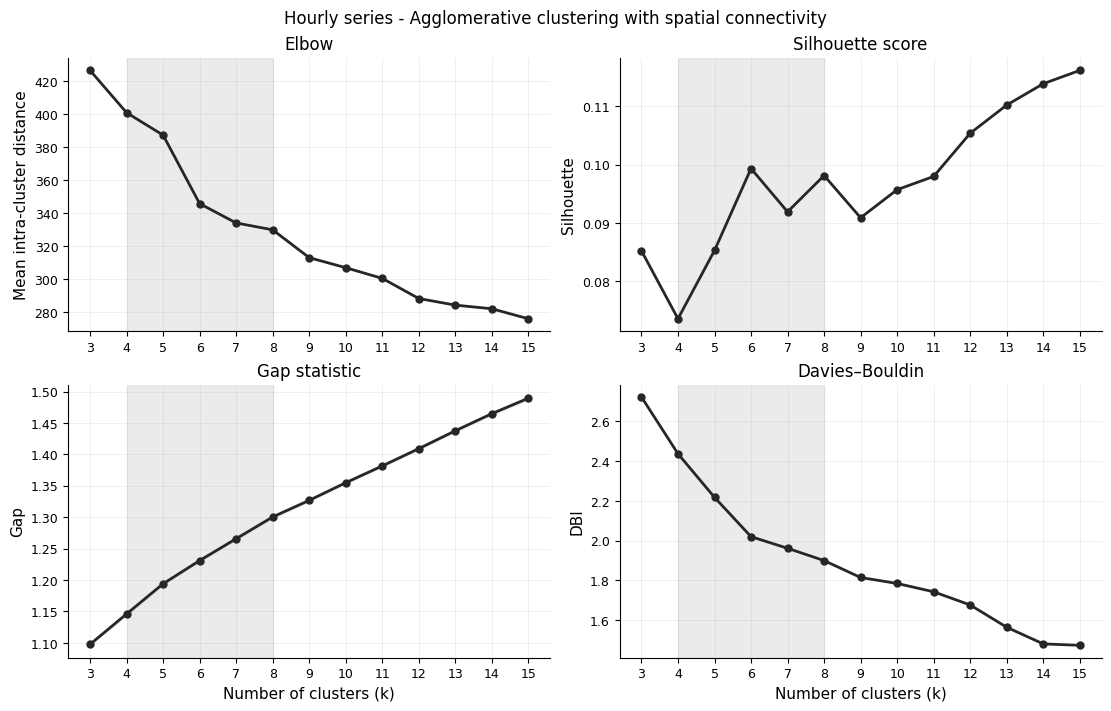

hourly
    mean_intra_dist  inertia_wcss  silhouette       gap    gap_sk  \
k                                                                   
3        426.499020  6.559054e+06    0.085222  1.097744  0.001576   
4        400.904818  6.151218e+06    0.073576  1.146088  0.001905   
5        387.294596  5.768510e+06    0.085282  1.194162  0.001601   
6        345.804504  5.472168e+06    0.099332  1.231060  0.001791   
7        334.126531  5.197499e+06    0.091911  1.265841  0.001658   
8        329.958328  4.937115e+06    0.098129  1.300477  0.001984   
9        313.093185  4.723815e+06    0.090893  1.326911  0.001817   
10       307.015988  4.516039e+06    0.095705  1.354972  0.001462   
11       300.557718  4.319692e+06    0.097976  1.381687  0.001610   
12       288.367220  4.129146e+06    0.105380  1.409169  0.001820   
13       284.358099  3.940365e+06    0.110216  1.437668  0.001550   
14       282.155863  3.763369e+06    0.113871  1.464858  0.002163   
15       276.104355  3.6031

/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)


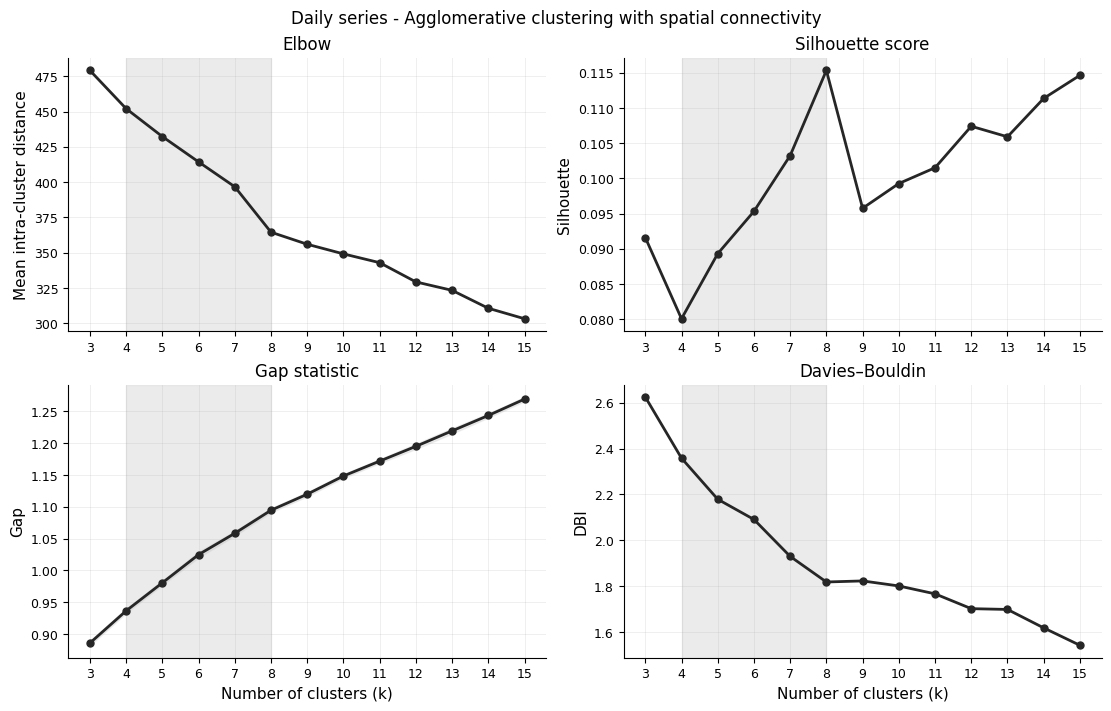

daily
    mean_intra_dist  inertia_wcss  silhouette       gap    gap_sk  \
k                                                                   
3        479.141379  8.454681e+06    0.091607  0.885964  0.003485   
4        452.069982  7.904118e+06    0.080072  0.936597  0.003478   
5        432.266368  7.431110e+06    0.089307  0.980623  0.003247   
6        414.312536  7.001601e+06    0.095322  1.024861  0.004525   
7        396.680091  6.649594e+06    0.103237  1.058381  0.003634   
8        364.486290  6.309246e+06    0.115328  1.094599  0.003277   
9        355.929804  6.040338e+06    0.095758  1.119788  0.003309   
10       349.105257  5.778173e+06    0.099271  1.148367  0.003116   
11       342.868748  5.542053e+06    0.101512  1.171765  0.003047   
12       329.240270  5.311422e+06    0.107400  1.194955  0.004032   
13       323.257101  5.089757e+06    0.105903  1.219249  0.004203   
14       310.563532  4.872574e+06    0.111357  1.243431  0.003312   
15       303.128396  4.66289

/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)


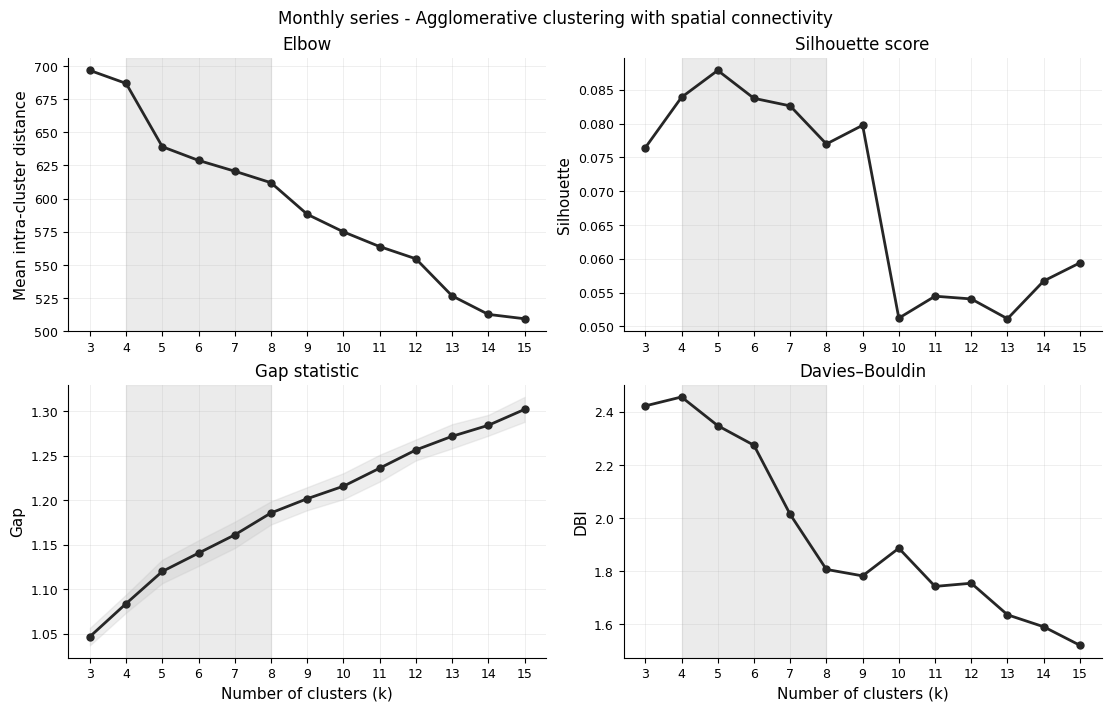

monthly
    mean_intra_dist  inertia_wcss  silhouette       gap    gap_sk  \
k                                                                   
3        696.587991  1.850590e+07    0.076415  1.046833  0.009715   
4        686.793842  1.741183e+07    0.083873  1.083942  0.010145   
5        639.058527  1.646385e+07    0.087852  1.120032  0.013200   
6        628.736616  1.574755e+07    0.083725  1.140607  0.014412   
7        620.586780  1.510303e+07    0.082605  1.161057  0.014768   
8        611.910851  1.448464e+07    0.076969  1.185672  0.012996   
9        588.116501  1.393512e+07    0.079739  1.201641  0.012934   
10       574.868391  1.341579e+07    0.051215  1.215679  0.014587   
11       563.758935  1.291763e+07    0.054458  1.235893  0.015029   
12       554.558467  1.243520e+07    0.054053  1.256353  0.011721   
13       526.593538  1.197591e+07    0.051122  1.271679  0.013570   
14       512.638053  1.152118e+07    0.056709  1.284017  0.011674   
15       509.347626  1.110

In [11]:
import os
import pandas as pd
import geopandas as gpd

dir_data  = '/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/'
ruta_coor = f'{dir_data}shape_files/'
out_dir   = "/home/oisanchezp/Thesis/results/02_Chapter"
os.makedirs(out_dir, exist_ok=True)

csvs = {
    "hourly":  {"path": os.path.join(dir_data, "all_stations_SIATA_hourly.csv"),  "fig": "fig03", "label": "Hourly"},
    "daily":   {"path": os.path.join(dir_data, "all_stations_SIATA_daily.csv"),   "fig": "fig04", "label": "Daily"},
    "monthly": {"path": os.path.join(dir_data, "all_stations_SIATA_monthly.csv"), "fig": "fig05", "label": "Monthly"},
}

pluvios = gpd.read_file(os.path.join(ruta_coor, "Est_All.shp")).set_index("codigo")

for escala, info in csvs.items():
    feats = pd.read_csv(info["path"], index_col=0, parse_dates=True).T.fillna(0)  # index=estaciones

    out, k_suggest, fig = evaluate_k_hourly(
        X_df=feats,
        pluvios_gdf=pluvios,
        ks=range(3, 16),
        use_scaler=False,
        use_pca=False,
        connectivity_mode="voronoi_queen",
        n_refs=30,
        random_state=42,
        title=f"{info['label']} series - Agglomerative clustering with spatial connectivity",
        shade_range=(4, 7),
        save_path=os.path.join(out_dir, f"{info['fig']}.png"),  # ✅ fig03/fig04/fig05
        dpi=300,
        show=True  # pon False si solo quieres guardar sin mostrar
    )

    print(escala)
    print(out)
    print("Suggested k:", k_suggest)


/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)


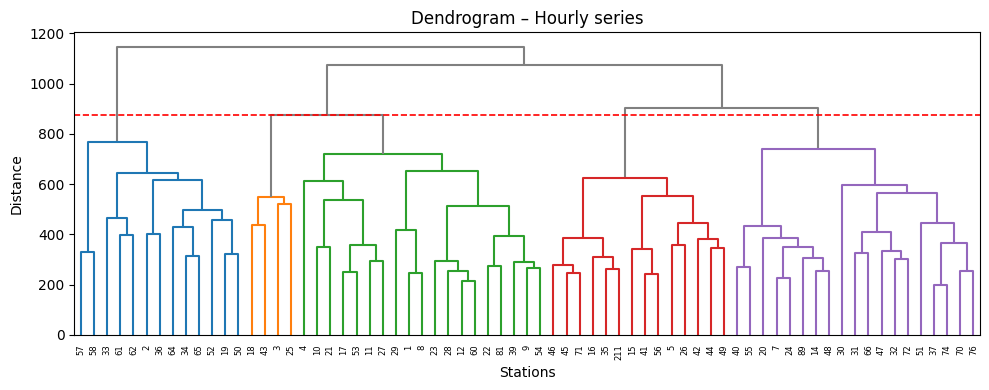

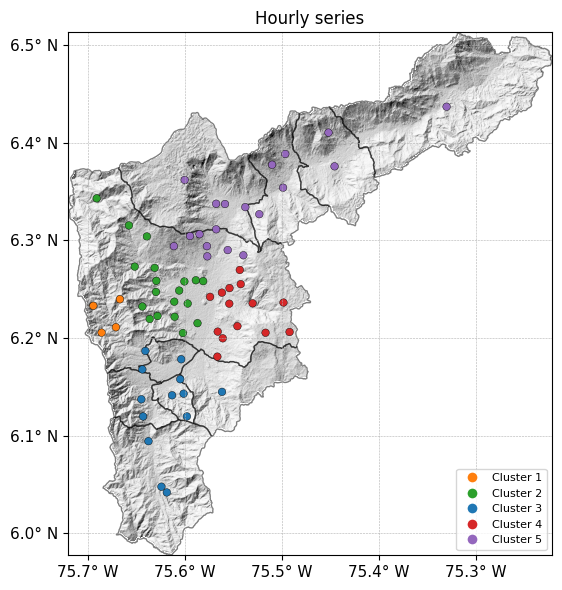

/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)


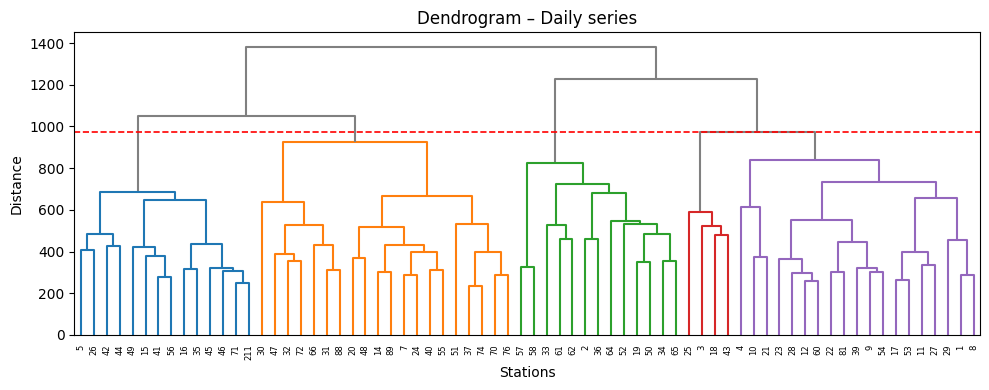

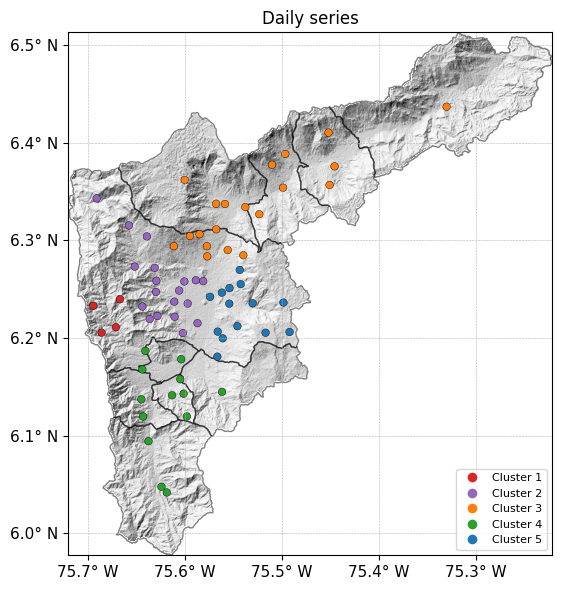

/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)


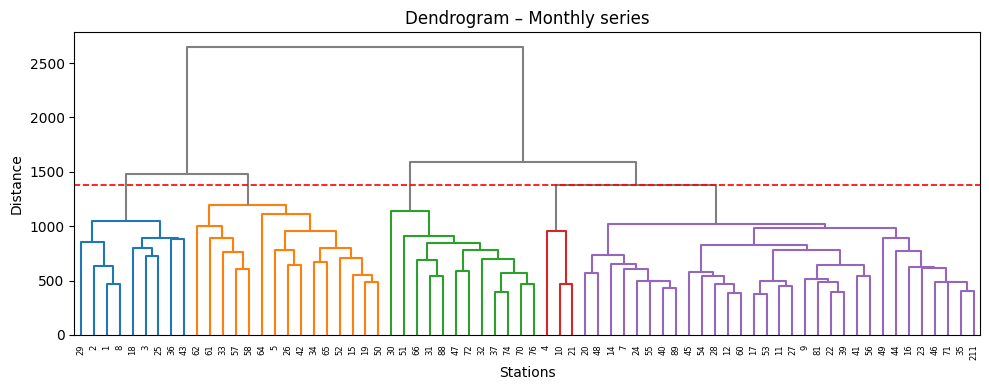

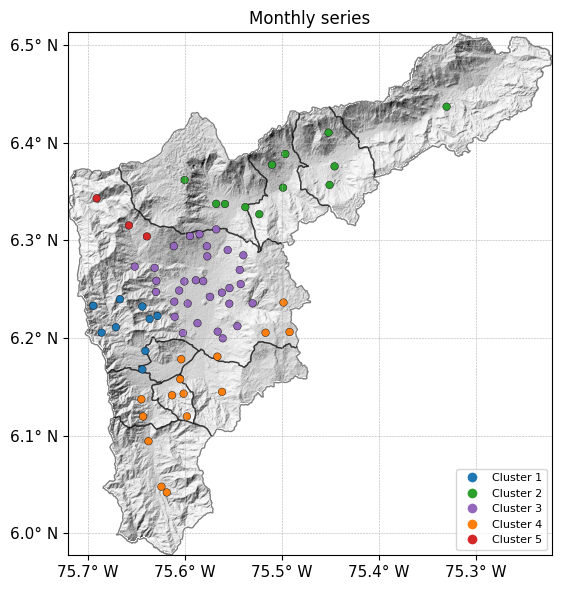

In [2]:
import os, numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
import rasterio as rio
from rasterio.plot import show
from functools import lru_cache
from matplotlib.ticker import FuncFormatter

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from libpysal.weights import Voronoi  # <-- para puntos (Thiessen/Voronoi)

# ─────────── CONFIGURACIÓN ────────────
dir_data   = '/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/'
ruta_coor  = os.path.join(dir_data, 'shape_files')
csvs       = {
    'hourly': os.path.join(dir_data, 'all_stations_SIATA_hourly.csv'),
    'daily' : os.path.join(dir_data, 'all_stations_SIATA_daily.csv'),
    'monthly': os.path.join(dir_data, 'all_stations_SIATA_monthly.csv')
}

pluvios  = gpd.read_file(f'{ruta_coor}/Est_All.shp').set_index('codigo')
hill_src = rio.open(f'{ruta_coor}/DEM_west_Hillshade_Clip_r.tif')
hill     = np.where((h := hill_src.read(1)) == h[0, 0], np.nan, h)
AMVA     = gpd.read_file(f'{ruta_coor}/mpios_amva_qnk.shp')

# ---- banderas (recomendación: True en hourly y daily)
USE_LOG1P   = False      # útil si quieres suavizar extremos de lluvia
USE_SCALER  = False       # recomendado
USE_PCA     = False       # recomendado en hourly/daily si hay muchísimas columnas (tiempo)
PCA_VAR     = 0.95       # varianza acumulada a retener
RANDOM_SEED = 42

# ─────────── util: sklearn metric/affinity ───────────
def _agglo_kwargs():
    import inspect
    params = inspect.signature(AgglomerativeClustering).parameters
    return {"metric": "euclidean"} if "metric" in params else {"affinity": "euclidean"}


def plot_cluster_map(gdf, color_col, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    show(hill, transform=hill_src.transform, ax=ax, cmap='Greys_r')
    AMVA.plot(ax=ax, facecolor='none', edgecolor='black', alpha=0.5)
    gdf.plot(ax=ax, color=gdf[color_col], edgecolor='k', markersize=30, linewidth=.3)

    handles = [Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=c, markersize=8,
                      label=f'Cluster {k}')
               for k, c in sorted(zip(gdf['cluster_opt'].unique(),
                                      gdf.groupby('cluster_opt')[color_col].first()))]
    ax.legend(handles=handles, loc='lower right', fontsize=8)
    ax.set_title(title, fontsize=12)
    ax.grid(ls='--', lw=0.4)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.1f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}° N"))
    ax.tick_params(labelsize=11)
    plt.tight_layout(); plt.show()


# ─────────── BUCLE PRINCIPAL ───────────
k_opt = 5
palette = [f'C{i}' for i in range(k_opt)]
cluster_results = {}

for escala, path_csv in csvs.items():
    # 1) leer: index=Fecha, columns=estaciones  -> transponer para tener filas=estaciones
    feats = pd.read_csv(path_csv, index_col=0, parse_dates=True)
    feats = feats.loc[:, feats.columns.notna()]  # por si hay columnas raras
    feats = feats.T.fillna(0)

    # 2) alinear con shapefile (puntos)
    feats.index = feats.index.astype(pluvios.index.dtype)
    feats = feats.loc[pluvios.index.intersection(feats.index)]
    gdf = pluvios.loc[feats.index].copy()

    # 3) conectividad espacial CORRECTA para puntos: Voronoi (queen)
    #    IMPORTANTE: si pluvios está en EPSG:4326, reproyecta antes (ideal a metros).
    coords = np.column_stack([gdf.geometry.x.values, gdf.geometry.y.values])
    conn = Voronoi(coords, criterion="queen").sparse

    # 4) matriz X (filas=estaciones, cols=tiempo/features)
    X = feats.values.astype(float)

    # opcional: suavizar extremos (lluvia es muy sesgada)
    if USE_LOG1P:
        X = np.log1p(X)

    # 5) estandarizar (por columna: cada instante/feature)
    if USE_SCALER:
        X = StandardScaler(with_mean=True, with_std=True).fit_transform(X)

    # 6) PCA (reduce dimensionalidad y correlación)
    if USE_PCA:
        X = PCA(n_components=PCA_VAR, svd_solver="full", random_state=RANDOM_SEED).fit_transform(X)

    # 7) ajustar árbol completo (para dendrograma)
    full = AgglomerativeClustering(
        n_clusters=None, distance_threshold=0.0,
        linkage='ward', connectivity=conn, **_agglo_kwargs()
    ).fit(X)

    # ─── linkage matrix para scipy.dendrogram ───
    n = len(full.labels_)
    cnt = np.zeros(full.children_.shape[0])
    for i, merge in enumerate(full.children_):
        cnt[i] = sum((1 if m < n else cnt[m - n]) for m in merge)
    link = np.column_stack([full.children_, full.distances_, cnt]).astype(float)

    # ─── umbral para k_opt (color threshold del dendrograma)
    # Nota: el umbral correcto es una ALTURA (distancia). Para k_opt clusters:
    # se corta justo antes de los últimos (k_opt-1) merges grandes.
    thr = link[-(k_opt - 1), 2]  # si esto no te corta bien, usa link[-(k_opt-1), 2]?? (ver nota abajo)

    # OJO: en 'link' la columna 2 es "count", no "distance". La distancia está en link[:, 2] si lo armas así:
    # aquí lo armamos [children, distances, count] => distances está en col=2 y count en col=3
    # Entonces el umbral real debe ser:
    thr = link[-(k_opt - 1), 2]

    # etiquetas finales (k_opt)
    labels = fcluster(link, k_opt, criterion='maxclust')

    colmap = {cl: palette[i] for i, cl in enumerate(np.sort(np.unique(labels)))}
    gdf['cluster_opt'] = labels
    gdf['color_opt']   = gdf['cluster_opt'].map(colmap)

    cluster_results[escala] = pd.Series(labels, index=feats.index)

    # ─── color para ramas del dendrograma ───
    @lru_cache(None)
    def nodo_cluster(i):
        if i < n:
            return labels[i]
        l, r = full.children_[i - n]
        cl_l, cl_r = nodo_cluster(l), nodo_cluster(r)
        return cl_l if cl_l == cl_r else None

    def link_color_func(i):
        cl = nodo_cluster(int(i))
        return colmap[cl] if cl is not None else '#808080'

    # ─── dendrograma ───
    sch.set_link_color_palette(palette)
    plt.figure(figsize=(10, 4))
    sch.dendrogram(
        link,
        labels=feats.index.astype(str),
        leaf_rotation=90,
        leaf_font_size=6,
        color_threshold=thr,
        link_color_func=link_color_func
    )
    plt.axhline(thr, c='r', ls='--', lw=1.2)
    plt.title(f'Dendrogram – {escala.capitalize()} series', fontsize=12)
    plt.ylabel('Distance')
    plt.xlabel('Stations')
    plt.tight_layout(); plt.show()

    # ─── mapa ───
    plot_cluster_map(gdf, 'color_opt', f'{escala.capitalize()} series')

# ─────────── GEOJSON DE SALIDA ───────────
col_names = {'hourly': 'hourly_cluster',
             'daily' : 'daily_cluster',
             'monthly': 'monthly_cluster'}

idx_all = sorted(set().union(*[sr.index for sr in cluster_results.values()]))
gdf_out = pluvios.loc[idx_all].copy()

for escala, serie in cluster_results.items():
    gdf_out[col_names[escala]] = serie

#out_path = os.path.join(dir_data, 'pluvios_clusters.geojson')
#gdf_out.to_file(out_path, driver='GeoJSON')
#print(f'GeoJSON guardado en: {out_path}')


/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)
/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)
/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)


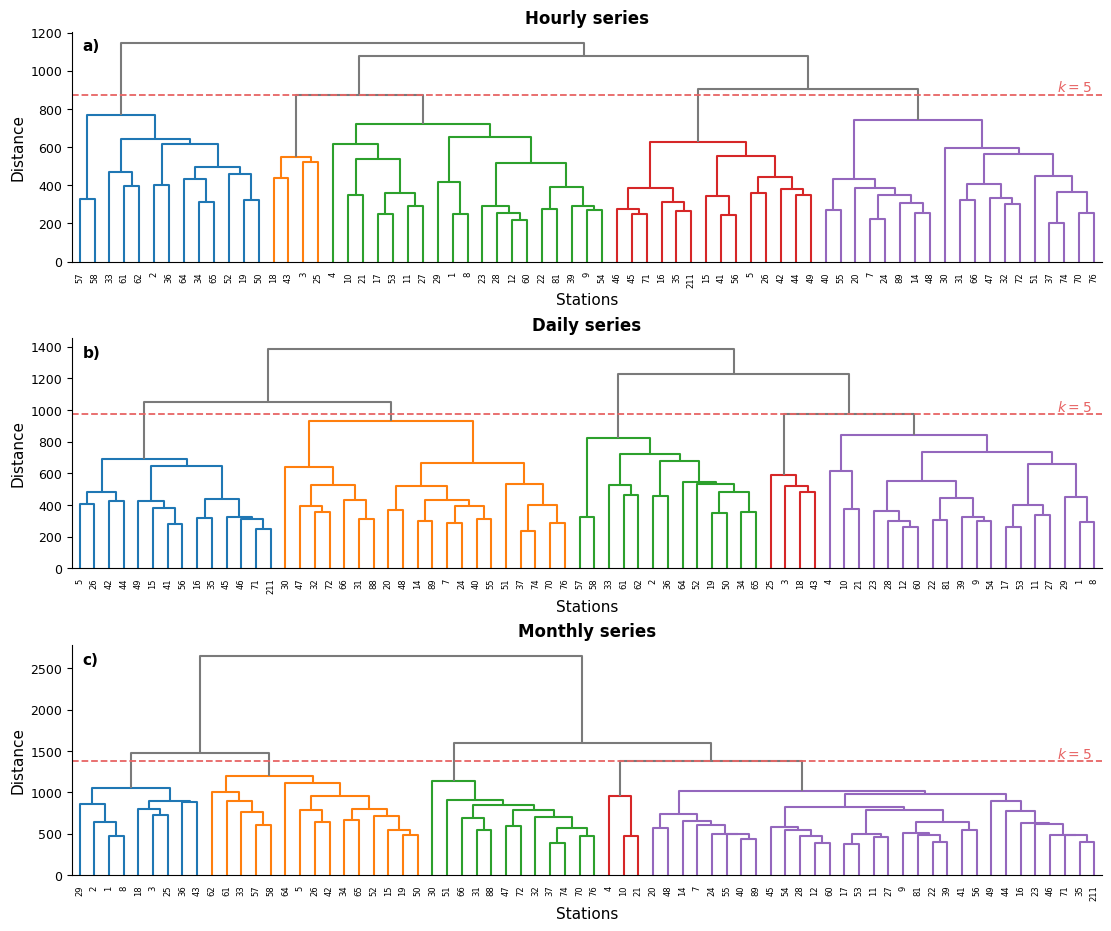

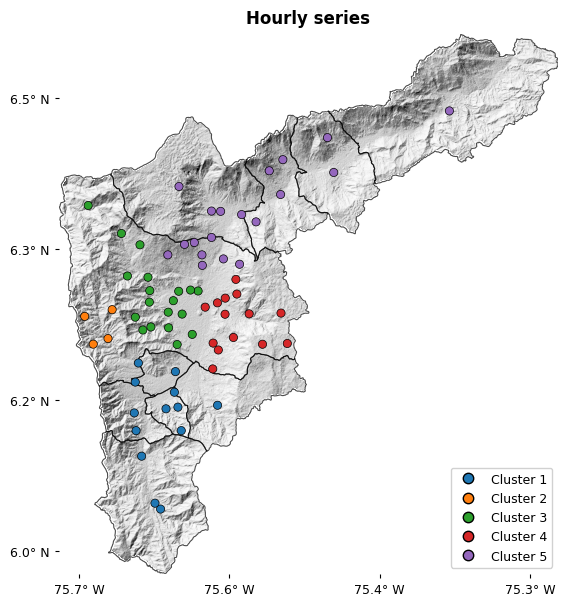

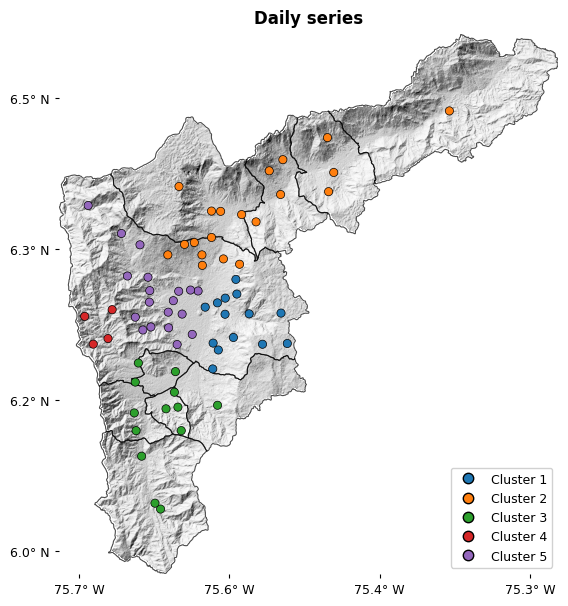

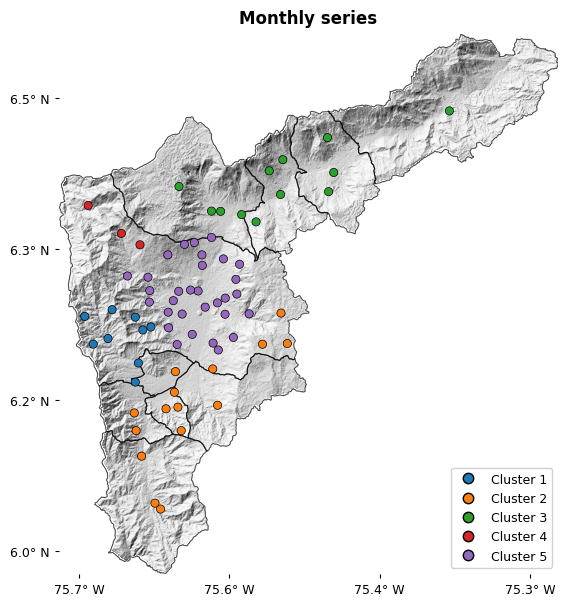

In [13]:
import os, numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
import rasterio as rio
from rasterio.plot import show
from functools import lru_cache
from matplotlib.ticker import FuncFormatter, MaxNLocator
from libpysal.weights import Voronoi

# ─────────────────────────────────────────────
# Estética global
# ─────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def _agglo_kwargs():
    import inspect
    params = inspect.signature(AgglomerativeClustering).parameters
    return {"metric": "euclidean"} if "metric" in params else {"affinity": "euclidean"}

# ─────────── CONFIGURACIÓN ────────────
dir_data   = '/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/'
ruta_coor  = os.path.join(dir_data, 'shape_files')

# ✅ BIEN: dict con path + nombre de figura
csvs = {
    "hourly":  {"path": os.path.join(dir_data, "all_stations_SIATA_hourly.csv"),  "fig": "fig07", "label": "Hourly"},
    "daily":   {"path": os.path.join(dir_data, "all_stations_SIATA_daily.csv"),   "fig": "fig08", "label": "Daily"},
    "monthly": {"path": os.path.join(dir_data, "all_stations_SIATA_monthly.csv"), "fig": "fig09", "label": "Monthly"},
}

out_dir = "/home/oisanchezp/Thesis/results/02_Chapter"
os.makedirs(out_dir, exist_ok=True)

pluvios  = gpd.read_file(f'{ruta_coor}/Est_All.shp').set_index('codigo')
hill_src = rio.open(f'{ruta_coor}/DEM_west_Hillshade_Clip_r.tif')
hill     = np.where((h := hill_src.read(1)) == h[0, 0], np.nan, h)
AMVA     = gpd.read_file(f'{ruta_coor}/mpios_amva_qnk.shp')

USE_LOG1P = False

# ─────────── MAPA ───────────
def plot_cluster_map(gdf, color_col, title, out_path=None, dpi=300, show_fig=True):
    fig, ax = plt.subplots(figsize=(6.2, 6.2))

    show(hill, transform=hill_src.transform, ax=ax, cmap='Greys_r')
    AMVA.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8, alpha=0.7)
    gdf.plot(ax=ax, color=gdf[color_col], edgecolor='black', markersize=35, linewidth=0.5, zorder=3)

    uniq = np.sort(gdf['cluster_opt'].unique())
    handles = []
    for k in uniq:
        c = gdf.loc[gdf['cluster_opt'] == k, color_col].iloc[0]
        handles.append(Line2D([0], [0], marker='o', color='w',
                              markerfacecolor=c, markeredgecolor='black',
                              markersize=7.5, label=f'Cluster {k}'))
    ax.legend(handles=handles, loc='lower right', frameon=True, framealpha=0.9)

    ax.set_title(title, pad=8, fontweight='bold')

    # ✅ pocos ticks (≈4)
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_locator(MaxNLocator(4))

    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.1f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}° N"))

    # ✅ sin spines, pero con ticks/labels
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="both", which="both", length=3, width=0.8, direction="out")
    ax.grid(False)

    plt.tight_layout()

    if out_path is not None:
        fig.savefig(out_path, dpi=dpi, bbox_inches='tight')

    if show_fig:
        plt.show()
    else:
        plt.close(fig)

# ─────────── Parámetros dendrograma ───────────
k_opt = 5
palette = [f'C{i}' for i in range(k_opt)]
letters = ["a)", "b)", "c)"]
order = [("hourly", "Hourly"), ("daily", "Daily"), ("monthly", "Monthly")]

dendro_pack = {}
map_pack = {}

# ─────────── PREPARAR (sin mostrar nada) ───────────
for escala, escala_lbl in order:
    path_csv = csvs[escala]["path"]

    feats = pd.read_csv(path_csv, index_col=0, parse_dates=True)
    feats = feats.loc[:, feats.columns.notna()]
    feats = feats.T.fillna(0)

    feats.index = feats.index.astype(pluvios.index.dtype)
    feats = feats.loc[pluvios.index.intersection(feats.index)]
    gdf = pluvios.loc[feats.index].copy()

    # conectividad: proyectar solo para vecindad si CRS geográfico
    gdf_conn = gdf
    if gdf_conn.crs is not None and getattr(gdf_conn.crs, "is_geographic", False):
        gdf_conn = gdf_conn.to_crs(3116)

    coords = np.column_stack([gdf_conn.geometry.x.values, gdf_conn.geometry.y.values])
    conn = Voronoi(coords, criterion="queen").sparse

    X = feats.values.astype(float)
    if USE_LOG1P:
        X = np.log1p(X)

    full = AgglomerativeClustering(
        n_clusters=None, distance_threshold=0.0,
        linkage='ward', connectivity=conn, **_agglo_kwargs()
    ).fit(X)

    n = len(full.labels_)
    cnt = np.zeros(full.children_.shape[0])
    for i, merge in enumerate(full.children_):
        cnt[i] = sum((1 if m < n else cnt[m - n]) for m in merge)
    link = np.column_stack([full.children_, full.distances_, cnt]).astype(float)

    # distancia umbral para k_opt
    thr = link[-(k_opt - 1), 2]

    labels = fcluster(link, k_opt, criterion='maxclust')
    colmap = {cl: palette[i] for i, cl in enumerate(np.sort(np.unique(labels)))}

    gdf['cluster_opt'] = labels
    gdf['color_opt']   = gdf['cluster_opt'].map(colmap)

    dendro_pack[escala] = dict(
        link=link, thr=thr, labels=labels, colmap=colmap, full=full, n=n, feats_index=feats.index
    )
    map_pack[escala] = gdf

# ─────────── FIGURA ÚNICA: 3 DENDROGRAMAS ───────────
fig_den, axes = plt.subplots(nrows=3, ncols=1, figsize=(11, 9.2), constrained_layout=True)

for idx, (escala, escala_lbl) in enumerate(order):
    pack = dendro_pack[escala]
    link, thr, labels, colmap, full, n = pack["link"], pack["thr"], pack["labels"], pack["colmap"], pack["full"], pack["n"]

    ax = axes[idx]
    sch.set_link_color_palette(palette)

    @lru_cache(None)
    def nodo_cluster(i):
        if i < n:
            return labels[i]
        l, r = full.children_[i - n]
        cl_l, cl_r = nodo_cluster(l), nodo_cluster(r)
        return cl_l if cl_l == cl_r else None

    def link_color_func(i):
        cl = nodo_cluster(int(i))
        return colmap[cl] if cl is not None else '#7a7a7a'

    sch.dendrogram(
        link,
        labels=pack["feats_index"].astype(str),
        leaf_rotation=90,
        leaf_font_size=6,
        color_threshold=thr,
        link_color_func=link_color_func,
        above_threshold_color="#7a7a7a",
        ax=ax
    )

    ax.axhline(thr, color="#E76464", linestyle="--", linewidth=1.3)

    # ✅ k = 5 sobre la línea
    ax.text(
        0.99, thr, rf"$k={k_opt}$",
        transform=ax.get_yaxis_transform(),
        ha="right", va="bottom",
        fontsize=10, fontweight="bold",
        color="#E76464"
    )

    ax.text(0.01, 0.97, letters[idx], transform=ax.transAxes,
            ha="left", va="top", fontweight="bold")

    ax.set_title(f"{escala_lbl} series", pad=6, fontweight="bold")
    ax.set_ylabel("Distance")
    ax.set_xlabel("Stations")

# ✅ guardar dendrogramas
fig_den.savefig(os.path.join(out_dir, "fig06.png"), dpi=300, bbox_inches="tight")
plt.show()

# ─────────── MAPAS (guardados + mostrados) ───────────
for escala, escala_lbl in order:
    out_map = os.path.join(out_dir, f"{csvs[escala]['fig']}.png")
    plot_cluster_map(
        map_pack[escala],
        color_col="color_opt",
        title=f"{escala_lbl} series",
        out_path=out_map,
        dpi=300,
        show_fig=True
    )


/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)
/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)
/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)


Mapeo horario (verificalo una vez): {5: 'Cluster 1', 1: 'Cluster 5', 2: 'Cluster 4', 4: 'Cluster 2', 3: 'Cluster 3'}


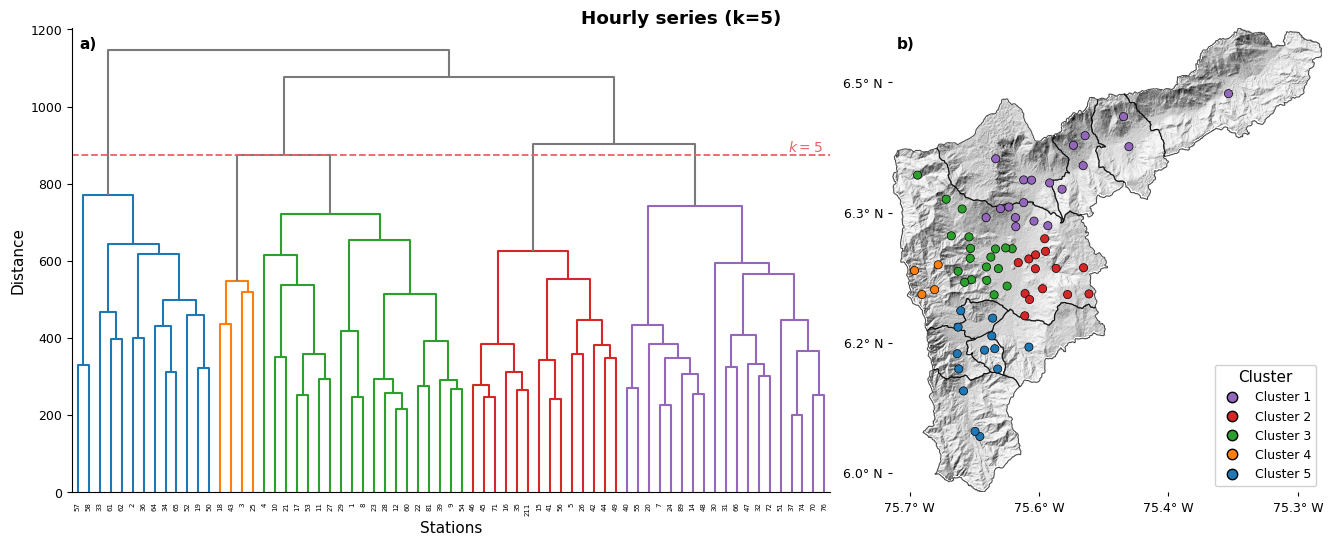

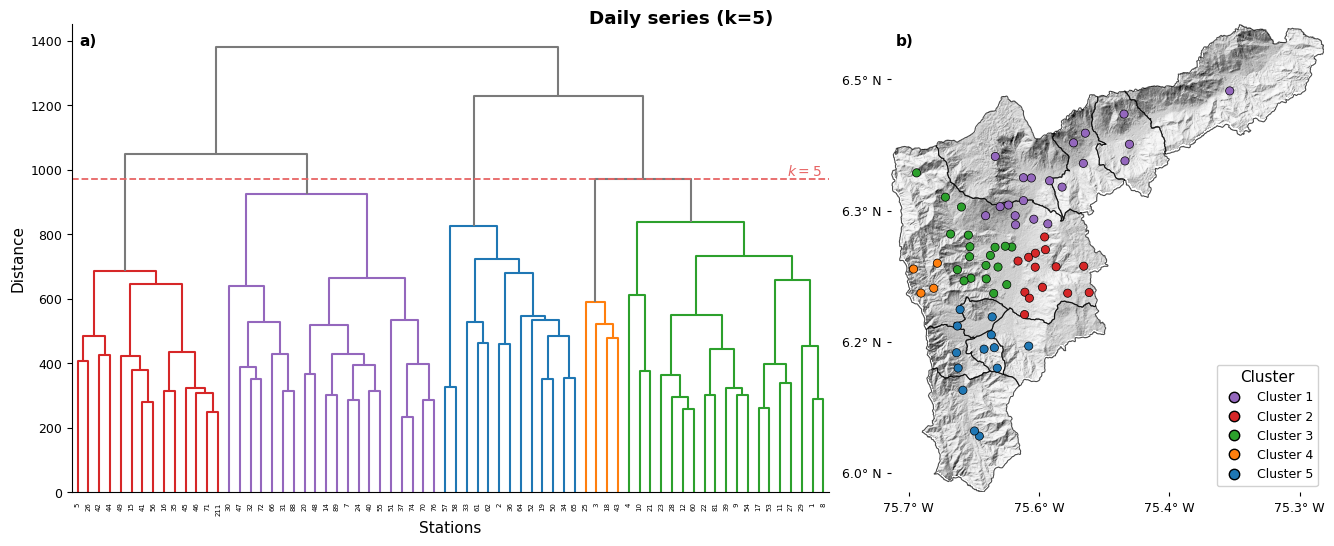

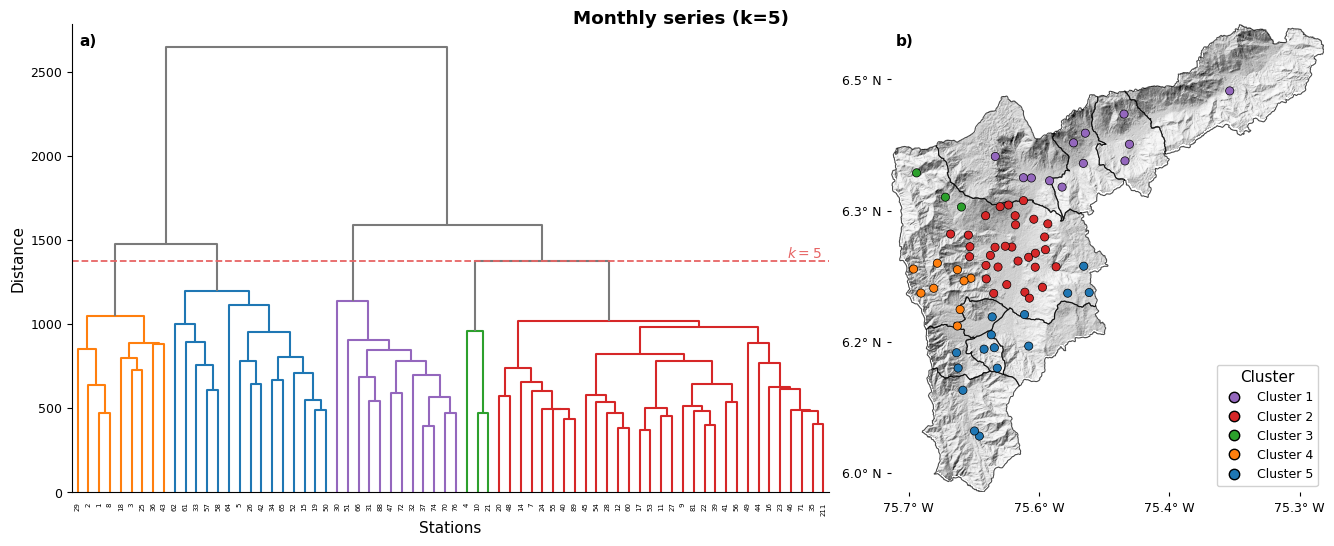

In [8]:
# =============================================================================
#  Figuras k=5 (dendrograma + mapa) con COLORES CONSISTENTES por cluster
#  en las tres escalas (horaria, diaria, mensual).
#
#  Idea: el color/numero NO depende del orden arbitrario de fcluster, sino de
#  la IDENTIDAD GEOGRAFICA del grupo (centroide). Asi, Cluster N y su color son
#  los mismos en horaria, diaria y mensual:
#     Cluster 1 (norte) -> morado | Cluster 2 (este) -> rojo
#     Cluster 3 (centro)-> verde  | Cluster 4 (oeste) -> naranja
#     Cluster 5 (sur)   -> azul
#  (Etiquetas provisionales tipo "Cluster N"; los nombres oficiales se pondran
#   despues.)
#
#  Orden de ejecucion dentro de la celda:
#   1) imports + estetica
#   2) config de clusters (colores) + funciones auxiliares
#   3) CONFIGURACION (paths, datos)
#   4) loop de PREPARACION (clustering, sin color)
#   5) PASO 2: referencia horaria -> asignar cluster + color a las 3 escalas
#   6) funciones de ploteo
#   7) loop de FIGURAS finales
# =============================================================================

import os, numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import AgglomerativeClustering
import rasterio as rio
from rasterio.plot import show
from functools import lru_cache
from matplotlib.ticker import FuncFormatter, MaxNLocator
from libpysal.weights import Voronoi
from matplotlib.gridspec import GridSpec

# ─────────────────────────────────────────────
# Estetica global
# ─────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def _agglo_kwargs():
    import inspect
    params = inspect.signature(AgglomerativeClustering).parameters
    return {"metric": "euclidean"} if "metric" in params else {"affinity": "euclidean"}

# ─────────────────────────────────────────────
# Config de CLUSTERS (colores fijos) + funciones auxiliares
# ─────────────────────────────────────────────
# Orden y color canonicos (FIJOS en todas las escalas)
ZONE_ORDER  = ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4", "Cluster 5"]
ZONE_COLORS = {
    "Cluster 1": "C4",   # morado
    "Cluster 2": "C3",   # rojo
    "Cluster 3": "C2",   # verde
    "Cluster 4": "C1",   # naranja
    "Cluster 5": "C0",   # azul
}

def name_reference_zones(gdf_ref, label_col="cluster_opt"):
    """Asigna 'Cluster N' a cada grupo de la particion de REFERENCIA (horaria)
    por la posicion geografica de su centroide, para que el numero/color sea
    estable entre escalas."""
    g = gdf_ref
    if gdf_ref.crs is not None and not gdf_ref.crs.is_geographic:
        g = gdf_ref.to_crs(4326)                       # lon/lat para nombrar
    cen = (pd.DataFrame({"lon": g.geometry.x.values,
                         "lat": g.geometry.y.values,
                         "lab": g[label_col].values})
             .groupby("lab")[["lon", "lat"]].mean())
    zones, rem = {}, list(cen.index)
    def take(idx): rem.remove(idx); return idx
    zones[take(cen.loc[rem, "lat"].idxmax())] = "Cluster 1"      # mas al norte
    zones[take(cen.loc[rem, "lat"].idxmin())] = "Cluster 5"      # mas al sur
    zones[take(cen.loc[rem, "lon"].idxmin())] = "Cluster 4"      # mas al oeste
    zones[take(cen.loc[rem, "lon"].idxmax())] = "Cluster 2"      # mas al este
    zones[rem[0]] = "Cluster 3"                                  # el restante
    return zones                                                # {label: "Cluster N"}

def map_labels_to_reference(labels_local, stations_local, ref_label_by_station):
    """Empareja 1:1 las etiquetas locales con las de referencia maximizando
    el solape de estaciones (asignacion hungara)."""
    s = pd.Series(labels_local, index=stations_local)
    common = s.index.intersection(ref_label_by_station.index)
    a, b = s.loc[common].to_numpy(), ref_label_by_station.loc[common].to_numpy()
    ua, ub = np.unique(a), np.unique(b)
    M = np.zeros((len(ua), len(ub)), dtype=int)
    for i, la in enumerate(ua):
        for j, lb in enumerate(ub):
            M[i, j] = np.sum((a == la) & (b == lb))
    ri, ci = linear_sum_assignment(-M)                # maximizar solape
    return {int(ua[i]): int(ub[j]) for i, j in zip(ri, ci)}

# ─────────── CONFIGURACION ────────────
dir_data   = '/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/'
ruta_coor  = os.path.join(dir_data, 'shape_files')

csvs = {
    "hourly":  {"path": os.path.join(dir_data, "all_stations_SIATA_hourly.csv"),  "fig": "fig07", "label": "Hourly"},
    "daily":   {"path": os.path.join(dir_data, "all_stations_SIATA_daily.csv"),   "fig": "fig08", "label": "Daily"},
    "monthly": {"path": os.path.join(dir_data, "all_stations_SIATA_monthly.csv"), "fig": "fig09", "label": "Monthly"},
}

out_dir = "/home/oisanchezp/Thesis/results/02_Chapter"
os.makedirs(out_dir, exist_ok=True)

pluvios  = gpd.read_file(f'{ruta_coor}/Est_All.shp').set_index('codigo')
hill_src = rio.open(f'{ruta_coor}/DEM_west_Hillshade_Clip_r.tif')
hill     = np.where((h := hill_src.read(1)) == h[0, 0], np.nan, h)
AMVA     = gpd.read_file(f'{ruta_coor}/mpios_amva_qnk.shp')

USE_LOG1P = False

# ─────────── Parametros dendrograma ───────────
k_opt = 5
palette = [f'C{i}' for i in range(k_opt)]
letters = ["a)", "b)", "c)"]
order = [("hourly", "Hourly"), ("daily", "Daily"), ("monthly", "Monthly")]

dendro_pack = {}
map_pack = {}

# ─────────── PASO 1: PREPARAR (clustering, SIN asignar color) ───────────
for escala, escala_lbl in order:
    path_csv = csvs[escala]["path"]
    feats = pd.read_csv(path_csv, index_col=0, parse_dates=True)
    feats = feats.loc[:, feats.columns.notna()]
    feats = feats.T.fillna(0)
    feats.index = feats.index.astype(pluvios.index.dtype)
    feats = feats.loc[pluvios.index.intersection(feats.index)]
    gdf = pluvios.loc[feats.index].copy()

    # conectividad: proyectar solo para vecindad si CRS geografico
    gdf_conn = gdf
    if gdf_conn.crs is not None and getattr(gdf_conn.crs, "is_geographic", False):
        gdf_conn = gdf_conn.to_crs(3116)
    coords = np.column_stack([gdf_conn.geometry.x.values, gdf_conn.geometry.y.values])
    conn = Voronoi(coords, criterion="queen").sparse

    X = feats.values.astype(float)
    if USE_LOG1P:
        X = np.log1p(X)

    full = AgglomerativeClustering(
        n_clusters=None, distance_threshold=0.0,
        linkage='ward', connectivity=conn, **_agglo_kwargs()
    ).fit(X)

    n = len(full.labels_)
    cnt = np.zeros(full.children_.shape[0])
    for i, merge in enumerate(full.children_):
        cnt[i] = sum((1 if m < n else cnt[m - n]) for m in merge)
    link = np.column_stack([full.children_, full.distances_, cnt]).astype(float)

    # distancia umbral para k_opt
    thr = link[-(k_opt - 1), 2]
    labels = fcluster(link, k_opt, criterion='maxclust')

    gdf['cluster_opt'] = labels   # color se asigna en el PASO 2

    dendro_pack[escala] = dict(
        link=link, thr=thr, labels=labels, full=full, n=n, feats_index=feats.index
    )
    map_pack[escala] = gdf

# ─────────── PASO 2: COLORES CONSISTENTES POR CLUSTER ───────────
# 1) Referencia = escala horaria (ya validada)
ref_labels   = pd.Series(dendro_pack["hourly"]["labels"],
                         index=dendro_pack["hourly"]["feats_index"])
ref_lab2zone = name_reference_zones(map_pack["hourly"])      # {label_horario: "Cluster N"}
print("Mapeo horario (verificalo una vez):", ref_lab2zone)

# 2) Asignar cluster + color en las tres escalas
for escala, _ in order:
    labels   = dendro_pack[escala]["labels"]
    stations = dendro_pack[escala]["feats_index"]
    if escala == "hourly":
        lab2zone = ref_lab2zone
    else:
        m = map_labels_to_reference(labels, stations, ref_labels)  # local -> horario
        lab2zone = {loc: ref_lab2zone[ref] for loc, ref in m.items()}
    colmap = {lab: ZONE_COLORS[lab2zone[lab]] for lab in np.unique(labels)}
    dendro_pack[escala]["colmap"]  = colmap                  # el dendrograma lo usa
    dendro_pack[escala]["lab2zone"] = lab2zone
    map_pack[escala]["zone"]       = map_pack[escala]["cluster_opt"].map(lab2zone)
    map_pack[escala]["color_opt"]  = map_pack[escala]["cluster_opt"].map(colmap)

# ─────────── Funciones de ploteo ───────────
def plot_dendrogram_ax(ax, pack, escala_lbl, k_opt, palette, letter="a)"):
    link   = pack["link"]
    thr    = pack["thr"]
    labels = pack["labels"]
    colmap = pack["colmap"]
    full   = pack["full"]
    n      = pack["n"]

    sch.set_link_color_palette(palette)

    @lru_cache(None)
    def nodo_cluster(i):
        if i < n:
            return labels[i]
        l, r = full.children_[i - n]
        cl_l, cl_r = nodo_cluster(l), nodo_cluster(r)
        return cl_l if cl_l == cl_r else None

    def link_color_func(i):
        cl = nodo_cluster(int(i))
        return colmap[cl] if cl is not None else "#7a7a7a"

    sch.dendrogram(
        link,
        labels=pack["feats_index"].astype(str),
        leaf_rotation=90,
        leaf_font_size=5,
        color_threshold=thr,
        link_color_func=link_color_func,
        above_threshold_color="#7a7a7a",
        ax=ax
    )
    ax.axhline(thr, color="#E76464", linestyle="--", linewidth=1.3)
    ax.text(
        0.99, thr, rf"$k={k_opt}$",
        transform=ax.get_yaxis_transform(),
        ha="right", va="bottom",
        fontsize=10, fontweight="bold",
        color="#E76464"
    )
    ax.text(0.01, 0.98, letter, transform=ax.transAxes,
            ha="left", va="top", fontweight="bold", fontsize=11)
    ax.set_ylabel("Distance")
    ax.set_xlabel("Stations")

def plot_cluster_map_ax(ax, gdf, color_col, title=None, letter="b)"):
    show(hill, transform=hill_src.transform, ax=ax, cmap="Greys_r")
    AMVA.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.8, alpha=0.7)
    gdf.plot(ax=ax, color=gdf[color_col], edgecolor="black",
             markersize=35, linewidth=0.5, zorder=3)

    # Leyenda FIJA por cluster (identica en las 3 figuras)
    handles = [Line2D([0], [0], marker="o", color="w",
                      markerfacecolor=ZONE_COLORS[z], markeredgecolor="black",
                      markersize=7.5, label=z) for z in ZONE_ORDER]
    ax.legend(handles=handles, loc="lower right", frameon=True,
              framealpha=0.9, title="Cluster")

    if title is not None:
        ax.set_title(title, pad=6, fontweight="bold")
    ax.text(0.01, 0.98, letter, transform=ax.transAxes,
            ha="left", va="top", fontweight="bold", fontsize=11)
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_locator(MaxNLocator(4))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.1f}° W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}° N"))
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="both", which="both", length=3, width=0.8, direction="out")
    ax.grid(False)

# ─────────────────────────────────────────────
# PASO 3: FIGURAS FINALES (1 por escala: dendrograma + mapa)
# ─────────────────────────────────────────────
for escala, escala_lbl in order:
    pack = dendro_pack[escala]
    gdf  = map_pack[escala]

    fig = plt.figure(figsize=(13.5, 5.2), constrained_layout=True)
    gs = GridSpec(1, 2, figure=fig, width_ratios=[1.55, 1.0])
    ax_den = fig.add_subplot(gs[0, 0])
    ax_map = fig.add_subplot(gs[0, 1])

    plot_dendrogram_ax(ax_den, pack, escala_lbl, k_opt, palette, letter="a)")
    plot_cluster_map_ax(ax_map, gdf, color_col="color_opt", title=None, letter="b)")

    fig.suptitle(f"{escala_lbl} series (k={k_opt})", fontweight="bold", y=1.02)

    out_path = os.path.join(out_dir, f"fig_k{k_opt}_{escala}.png")  # fig_k5_hourly.png, ...
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

# **ARGUMENTAR POR QUE ESCOGIMOS K=5**

In [9]:
# ════════════════════════════════════════════════════════════════
# OPCIÓN B — Soporte para selección de k=5
# Helper functions: ajuste multi-k + métricas + propiedades + ARI
# ════════════════════════════════════════════════════════════════
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, adjusted_rand_score
)
from scipy.cluster.hierarchy import fcluster


def load_scale(path_csv, pluvios_gdf, use_log1p=False,
               use_scaler=False, use_pca=False,
               pca_var=0.95, random_seed=42, crs_proj=3116):
    """
    Carga y preprocesa los datos de una escala temporal.

    Returns
    -------
    feats : pd.DataFrame con filas=estaciones, columnas=tiempo
    gdf   : GeoDataFrame alineado con feats (CRS original)
    X     : np.ndarray con la matriz de features ya preprocesada
    conn  : sparse adjacency matrix (Voronoi-Queen)
    """
    feats = pd.read_csv(path_csv, index_col=0, parse_dates=True)
    feats = feats.loc[:, feats.columns.notna()]
    feats = feats.T.fillna(0)

    feats.index = feats.index.astype(pluvios_gdf.index.dtype)
    feats = feats.loc[pluvios_gdf.index.intersection(feats.index)]
    gdf = pluvios_gdf.loc[feats.index].copy()

    # Conectividad: reproyectar solo para construir vecindad
    gdf_conn = gdf
    if gdf_conn.crs is not None and getattr(gdf_conn.crs, "is_geographic", False):
        gdf_conn = gdf_conn.to_crs(crs_proj)

    coords = np.column_stack(
        [gdf_conn.geometry.x.values, gdf_conn.geometry.y.values]
    )
    conn = Voronoi(coords, criterion="queen").sparse

    X = feats.values.astype(float)
    if use_log1p:
        X = np.log1p(X)
    if use_scaler:
        X = StandardScaler(with_mean=True, with_std=True).fit_transform(X)
    if use_pca:
        X = PCA(n_components=pca_var, svd_solver="full",
                random_state=random_seed).fit_transform(X)

    return feats, gdf, X, conn


def fit_full_tree(X, conn):
    """
    Ajusta el árbol completo (sin cortar) y devuelve linkage scipy-style.
    """
    full = AgglomerativeClustering(
        n_clusters=None, distance_threshold=0.0,
        linkage="ward", connectivity=conn, **_agglo_kwargs()
    ).fit(X)
    n = len(full.labels_)
    cnt = np.zeros(full.children_.shape[0])
    for i, merge in enumerate(full.children_):
        cnt[i] = sum((1 if m < n else cnt[m - n]) for m in merge)
    link = np.column_stack(
        [full.children_, full.distances_, cnt]
    ).astype(float)
    return full, link, n


def partition_properties(labels, link, k):
    """
    Propiedades estructurales de una partición:
      - n_min, n_max : tamaño mínimo/máximo de cluster
      - sigma_n      : desviación estándar de tamaños (balance)
      - n_singletons : número de clusters con una sola estación
      - delta_h      : salto vertical en el dendrograma justo encima del corte
                       (distancia para k clusters menos distancia para k+1)
    """
    sizes = pd.Series(labels).value_counts()
    n_singletons = int((sizes == 1).sum())

    if k > 1 and len(link) >= k:
        d_k = float(link[-(k - 1), 2])
        d_kp1 = float(link[-k, 2]) if k <= len(link) else 0.0
        delta_h = d_k - d_kp1
    else:
        delta_h = np.nan

    return {
        "n_min": int(sizes.min()),
        "n_max": int(sizes.max()),
        "sigma_n": float(sizes.std(ddof=1)),
        "n_singletons": n_singletons,
        "delta_h": delta_h,
    }


def compute_k_table(X, link, ks=(4, 5, 6, 7, 8)):
    """
    Para una escala temporal dada, construye la tabla de diagnósticos
    para los k candidatos en ks. Reutiliza el árbol ya ajustado (link).
    """
    rows = []
    for k in ks:
        labels = fcluster(link, k, criterion="maxclust")
        row = {
            "k": k,
            "mean_intra_dist": mean_intra_cluster_distance(X, labels),
            "silhouette": silhouette_score(X, labels, metric="euclidean"),
            "davies_bouldin": davies_bouldin_score(X, labels),
        }
        row.update(partition_properties(labels, link, k))
        rows.append(row)
    return pd.DataFrame(rows).set_index("k")


def ari_between_scales(labels_dict):
    """
    Calcula la matriz ARI entre todas las escalas.

    Parameters
    ----------
    labels_dict : dict[str, pd.Series]
        Mapeo {escala: pd.Series(labels, index=estaciones)} para una misma k.

    Returns
    -------
    pd.DataFrame simétrica con los ARI entre pares.
    """
    scales = list(labels_dict.keys())
    M = pd.DataFrame(index=scales, columns=scales, dtype=float)
    for s1 in scales:
        for s2 in scales:
            # Alinear por estaciones comunes
            common = labels_dict[s1].index.intersection(labels_dict[s2].index)
            M.loc[s1, s2] = adjusted_rand_score(
                labels_dict[s1].loc[common].values,
                labels_dict[s2].loc[common].values,
            )
    return M

In [10]:
# ════════════════════════════════════════════════════════════════
# Construir la tabla de diagnósticos para k=4..8 en las 3 escalas
# (versión simplificada: solo S_k y Δh)
# ════════════════════════════════════════════════════════════════
ks_candidates = (4, 5, 6, 7, 8)
order_scales = [("hourly", "Hourly"), ("daily", "Daily"), ("monthly", "Monthly")]

# Para reutilizar después en la figura comparativa y en ARI
trees = {}      # {escala: dict con link, X, gdf, feats}
labels_k = {}   # {(escala, k): pd.Series(labels, index=estaciones)}
tables = {}     # {escala: pd.DataFrame con métricas}

for escala, _ in order_scales:
    feats, gdf, X, conn = load_scale(
        csvs[escala]["path"], pluvios,
        use_log1p=USE_LOG1P, use_scaler=USE_SCALER,
        use_pca=USE_PCA, pca_var=PCA_VAR, random_seed=RANDOM_SEED,
    )
    full, link, n = fit_full_tree(X, conn)
    trees[escala] = dict(feats=feats, gdf=gdf, X=X, link=link, full=full, n=n)

    tables[escala] = compute_k_table(X, link, ks=ks_candidates)

    for k in ks_candidates:
        lab = fcluster(link, k, criterion="maxclust")
        labels_k[(escala, k)] = pd.Series(lab, index=feats.index, name=f"k{k}")

# Tabla consolidada para mostrar / exportar
tbl_consol = pd.concat(
    {escala: tables[escala] for escala, _ in order_scales},
    names=["scale", "k"]
)

# Redondeo amigable para presentación
tbl_consol_round = tbl_consol.copy()
tbl_consol_round[["delta_h"]] = tbl_consol_round[["delta_h"]].round(1)
tbl_consol_round[["silhouette"]] = tbl_consol_round[["silhouette"]].round(3)

print(tbl_consol_round[["silhouette", "delta_h"]])


# ════════════════════════════════════════════════════════════════
# Generador LaTeX — versión reducida: solo S_k y Δh
# ════════════════════════════════════════════════════════════════
def tbl_to_latex_tabularx_reduced(tbl_consol, ks_candidates, order_scales,
                                  precision=3, out_path=None):
    """
    Versión simplificada: solo 2 métricas (S_k, Δh) por escala.
    Mantiene el estilo tabularx con bordes y agrupación por escala.
    """
    cols_show  = ["silhouette", "delta_h"]
    col_labels = [r"$S_k$", r"$\Delta h$"]

    scales_keys = [s for s, _ in order_scales]
    scales_lbl  = [lbl for _, lbl in order_scales]
    n_scales    = len(scales_keys)
    n_metrics   = len(cols_show)

    def fmt_value(v, col):
        if pd.isna(v):
            return "--"
        if col == "silhouette":
            return f"{v:.{precision}f}"
        if col == "delta_h":
            return f"{v:.1f}"
        return f"{v}"

    # Cabecera principal: escalas con \multicolumn
    top_cells = [r"\multirow{2}{*}{\textbf{$k$}}"]
    for i, lbl in enumerate(scales_lbl):
        align = "c|" if i < n_scales - 1 else "c"
        top_cells.append(
            rf"\multicolumn{{{n_metrics}}}{{{align}}}{{\textbf{{{lbl}}}}}"
        )
    top_header = " & ".join(top_cells) + r" \\"

    # \cline cruzando solo las columnas de escalas
    total_cols = 1 + n_scales * n_metrics  # 1 + 3*2 = 7
    cline = rf"\cline{{2-{total_cols}}}"

    # Sub-cabecera con S_k y Δh repetidos por escala
    sub_cells = [""]
    for _ in scales_keys:
        sub_cells.extend([rf"\textbf{{{c}}}" for c in col_labels])
    sub_header = " & ".join(sub_cells) + r" \\"

    # Cuerpo
    body_lines = []
    for k_val in ks_candidates:
        cells = [str(k_val)]
        for s in scales_keys:
            row = tbl_consol.loc[(s, k_val)]
            for c in cols_show:
                cells.append(fmt_value(row[c], c))
        body_lines.append(" & ".join(cells) + r" \\")

    # Especificación de columnas: m{0.8cm} + (Y Y |) repetido
    col_groups = []
    for i in range(n_scales):
        sep = " | " if i < n_scales - 1 else ""
        col_groups.append(" ".join(["Y"] * n_metrics) + sep)
    col_spec = r">{\centering\arraybackslash}m{0.8cm} " + " ".join(col_groups)

    body_block = "\n\\hline\n".join(body_lines)

    tex = (
        "\\renewcommand{\\arraystretch}{1.25}\n"
        "\\setlength{\\tabcolsep}{5pt}\n"
        "\\begin{table}[h]\n"
        "\\centering\n"
        "\\newcolumntype{Y}{>{\\centering\\arraybackslash}X}\n"
        f"\\begin{{tabularx}}{{\\textwidth}}{{{col_spec}}}\n"
        "\\hline\n"
        f"{top_header}\n"
        f"{cline}\n"
        f"{sub_header}\n"
        "\\hline\n"
        f"{body_block}\n"
        "\\hline\n"
        "\\end{tabularx}\n"
        "\\caption{Cluster-validity diagnostics for candidate numbers of "
        "clusters ($k=4$--8) across the hourly, daily, and monthly "
        "aggregations. $S_k$: mean silhouette score (higher indicates "
        "better cohesion and separation); $\\Delta h$: dendrogram jump "
        "immediately above the cut (larger indicates a more natural "
        "partition, i.e., the algorithm is forced to merge groups whose "
        "internal dissimilarity is substantially higher than at the cut "
        "level).}\n"
        "\\label{tab:kselect}\n"
        "\\end{table}\n"
    )

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(tex)
        print(f"\nTabla LaTeX guardada en: {out_path}")

    return tex


out_tex = "/home/oisanchezp/Thesis/results/03_Chapter/tab_kselect.tex"
tex_str = tbl_to_latex_tabularx_reduced(
    tbl_consol,
    ks_candidates=ks_candidates,
    order_scales=order_scales,
    precision=3,
    out_path=out_tex,
)

print("\n" + "=" * 70)
print("Vista previa del LaTeX generado:")
print("=" * 70)
print(tex_str)

/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)


           silhouette  delta_h
scale   k                     
hourly  4       0.074     28.3
        5       0.085    105.0
        6       0.099     28.7
        7       0.092     19.5
        8       0.098     68.5
daily   4       0.080     76.7
        5       0.089     45.8
        6       0.095     87.8
        7       0.103     14.0
        8       0.115     91.7
monthly 4       0.084    102.3
        5       0.088    180.0
        6       0.084     61.6
        7       0.083     23.2
        8       0.077     63.8

Tabla LaTeX guardada en: /home/oisanchezp/Thesis/results/03_Chapter/tab_kselect.tex

Vista previa del LaTeX generado:
\renewcommand{\arraystretch}{1.25}
\setlength{\tabcolsep}{5pt}
\begin{table}[h]
\centering
\newcolumntype{Y}{>{\centering\arraybackslash}X}
\begin{tabularx}{\textwidth}{>{\centering\arraybackslash}m{0.8cm} Y Y |  Y Y |  Y Y}
\hline
\multirow{2}{*}{\textbf{$k$}} & \multicolumn{2}{c|}{\textbf{Hourly}} & \multicolumn{2}{c|}{\textbf{Daily}} & \multicolumn{

/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)
/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)


## **Tabla comparativa de métricas para k = 4,5,6,7 y 8**

In [11]:
# ════════════════════════════════════════════════════════════════
# Construir la tabla de diagnósticos para k=4..8 en las 3 escalas
# ════════════════════════════════════════════════════════════════
ks_candidates = (4, 5, 6, 7, 8)
order_scales = [("hourly", "Hourly"), ("daily", "Daily"), ("monthly", "Monthly")]

# Para reutilizar después en la figura comparativa y en ARI
trees = {}      # {escala: dict con link, X, gdf, feats}
labels_k = {}   # {(escala, k): pd.Series(labels, index=estaciones)}
tables = {}     # {escala: pd.DataFrame con métricas}

for escala, _ in order_scales:
    feats, gdf, X, conn = load_scale(
        csvs[escala]["path"], pluvios,
        use_log1p=USE_LOG1P, use_scaler=USE_SCALER,
        use_pca=USE_PCA, pca_var=PCA_VAR, random_seed=RANDOM_SEED,
    )
    full, link, n = fit_full_tree(X, conn)
    trees[escala] = dict(feats=feats, gdf=gdf, X=X, link=link, full=full, n=n)

    tables[escala] = compute_k_table(X, link, ks=ks_candidates)

    for k in ks_candidates:
        lab = fcluster(link, k, criterion="maxclust")
        labels_k[(escala, k)] = pd.Series(lab, index=feats.index, name=f"k{k}")

# Tabla consolidada para mostrar / exportar
tbl_consol = pd.concat(
    {escala: tables[escala] for escala, _ in order_scales},
    names=["scale", "k"]
)

# Redondeo amigable para presentación
tbl_consol_round = tbl_consol.copy()
tbl_consol_round[["mean_intra_dist", "delta_h"]] = (
    tbl_consol_round[["mean_intra_dist", "delta_h"]].round(1)
)
tbl_consol_round[["silhouette", "davies_bouldin", "sigma_n"]] = (
    tbl_consol_round[["silhouette", "davies_bouldin", "sigma_n"]].round(3)
)

print(tbl_consol_round)

# Exportar para LaTeX (opcional)
out_tex = "/home/oisanchezp/Thesis/results/03_Chapter/tab_kselect.tex"
os.makedirs(os.path.dirname(out_tex), exist_ok=True)
tbl_consol_round.to_latex(
    out_tex,
    float_format="%.3f",
    caption=(
        "Cluster-validity and partition properties for $k=4,\\dots,8$ "
        "across hourly, daily, and monthly aggregations. "
        "Lower DBI and mean intra-cluster distance, higher silhouette and "
        "$\\Delta h$, and fewer singletons indicate more defensible partitions."
    ),
    label="tab:kselect",
)
print(f"\nTabla LaTeX guardada en: {out_tex}")

/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)
/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)
/home/oisanchezp/geo_env/lib/python3.8/site-packages/libpysal/weights/contiguity.py:641: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  return cls.from_dataframe(region_df, **kwargs)


           mean_intra_dist  silhouette  davies_bouldin  n_min  n_max  sigma_n  \
scale   k                                                                       
hourly  4            400.9       0.074           2.437     13     23    4.646   
        5            387.3       0.085           2.218      4     19    6.140   
        6            345.8       0.099           2.020      2     19    7.287   
        7            334.1       0.092           1.962      2     19    5.815   
        8            330.0       0.098           1.900      2     14    4.138   
daily   4            452.1       0.080           2.358     13     23    4.796   
        5            432.3       0.089           2.179      4     20    6.364   
        6            414.3       0.095           2.091      4     19    5.354   
        7            396.7       0.103           1.930      3     16    5.228   
        8            364.5       0.115           1.818      2     16    5.445   
monthly 4            686.8  

In [12]:
# ════════════════════════════════════════════════════════════════
# Generador LaTeX — Opción A (tabularx con bordes, agrupado por escala)
# ════════════════════════════════════════════════════════════════
def tbl_to_latex_tabularx(tbl_consol, ks_candidates, order_scales,
                          precision=3, out_path=None):
    """
    Convierte la tabla consolidada de métricas a LaTeX con el estilo
    'Opción A': tabularx, bordes \hline horizontales y verticales entre
    grupos de escala. Columnas agrupadas por escala temporal.

    Parameters
    ----------
    tbl_consol : pd.DataFrame con MultiIndex (scale, k).
    ks_candidates : iterable con los valores de k a incluir.
    order_scales : list of (key, label) para definir orden y nombre.
    precision : decimales para métricas continuas.
    out_path : ruta para guardar el .tex (opcional).

    Returns
    -------
    str con el código LaTeX.
    """
    # Métricas a mostrar y etiquetas
    cols_show  = ["silhouette", "davies_bouldin", "n_singletons", "delta_h"]
    col_labels = [r"$S_k$", r"DBI", r"$n_s$", r"$\Delta h$"]

    scales_keys = [s for s, _ in order_scales]
    scales_lbl  = [lbl for _, lbl in order_scales]
    n_scales    = len(scales_keys)
    n_metrics   = len(cols_show)

    # Formateadores por columna
    def fmt_value(v, col):
        if pd.isna(v):
            return "--"
        if col in ("silhouette", "davies_bouldin", "delta_h"):
            return f"{v:.{precision}f}"
        return f"{int(v)}"

    # ── Cabecera principal: escalas con \multicolumn ───────────────
    # Para n_scales=3: \multicolumn{4}{c|}{Hourly} & ... & \multicolumn{4}{c}{Monthly}
    top_cells = [r"\multirow{2}{*}{\textbf{$k$}}"]
    for i, lbl in enumerate(scales_lbl):
        align = "c|" if i < n_scales - 1 else "c"
        top_cells.append(
            rf"\multicolumn{{{n_metrics}}}{{{align}}}{{\textbf{{{lbl}}}}}"
        )
    top_header = " & ".join(top_cells) + r" \\"

    # ── \cline que cruza solo las columnas de escalas ──────────────
    total_cols = 1 + n_scales * n_metrics
    cline = rf"\cline{{2-{total_cols}}}"

    # ── Sub-cabecera: métricas repetidas por escala ────────────────
    sub_cells = [""]
    for _ in scales_keys:
        sub_cells.extend([rf"\textbf{{{c}}}" for c in col_labels])
    sub_header = " & ".join(sub_cells) + r" \\"

    # ── Cuerpo: una fila por k ─────────────────────────────────────
    body_lines = []
    for k_val in ks_candidates:
        cells = [str(k_val)]
        for s in scales_keys:
            row = tbl_consol.loc[(s, k_val)]
            for c in cols_show:
                cells.append(fmt_value(row[c], c))
        body_lines.append(" & ".join(cells) + r" \\")

    # ── Especificación de columnas: m{0.8cm} + (Y Y Y Y |) repetido
    col_groups = []
    for i in range(n_scales):
        sep = " | " if i < n_scales - 1 else ""
        col_groups.append(" ".join(["Y"] * n_metrics) + sep)
    col_spec = r">{\centering\arraybackslash}m{0.8cm} " + " ".join(col_groups)

    # ── Ensamblar el bloque LaTeX completo ─────────────────────────
    body_block = "\n\\hline\n".join(body_lines)

    tex = (
        "\\renewcommand{\\arraystretch}{1.25}\n"
        "\\setlength{\\tabcolsep}{5pt}\n"
        "\\begin{table}[h]\n"
        "\\centering\n"
        "\\newcolumntype{Y}{>{\\centering\\arraybackslash}X}\n"
        f"\\begin{{tabularx}}{{\\textwidth}}{{{col_spec}}}\n"
        "\\hline\n"
        f"{top_header}\n"
        f"{cline}\n"
        f"{sub_header}\n"
        "\\hline\n"
        f"{body_block}\n"
        "\\hline\n"
        "\\end{tabularx}\n"
        "\\caption{Cluster-validity and partition properties for candidate "
        "numbers of clusters ($k=4$--8) across the hourly, daily, and "
        "monthly aggregations. "
        "$S_k$: mean silhouette score (higher is better); "
        "DBI: Davies--Bouldin index (lower is better); "
        "$n_s$: number of singleton clusters; "
        "$\\Delta h$: dendrogram jump immediately above the cut "
        "(larger indicates a more natural partition).}\n"
        "\\label{tab:kselect}\n"
        "\\end{table}\n"
    )

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(tex)
        print(f"\nTabla LaTeX guardada en: {out_path}")

    return tex


# ── Generar y guardar el .tex ──────────────────────────────────────
out_tex = "/home/oisanchezp/Thesis/results/03_Chapter/tab_kselect.tex"
tex_str = tbl_to_latex_tabularx(
    tbl_consol,
    ks_candidates=ks_candidates,
    order_scales=order_scales,
    precision=3,
    out_path=out_tex,
)

print("\n" + "=" * 70)
print("Vista previa del código LaTeX generado:")
print("=" * 70)
print(tex_str)


Tabla LaTeX guardada en: /home/oisanchezp/Thesis/results/03_Chapter/tab_kselect.tex

Vista previa del código LaTeX generado:
\renewcommand{\arraystretch}{1.25}
\setlength{\tabcolsep}{5pt}
\begin{table}[h]
\centering
\newcolumntype{Y}{>{\centering\arraybackslash}X}
\begin{tabularx}{\textwidth}{>{\centering\arraybackslash}m{0.8cm} Y Y Y Y |  Y Y Y Y |  Y Y Y Y}
\hline
\multirow{2}{*}{\textbf{$k$}} & \multicolumn{4}{c|}{\textbf{Hourly}} & \multicolumn{4}{c|}{\textbf{Daily}} & \multicolumn{4}{c}{\textbf{Monthly}} \\
\cline{2-13}
 & \textbf{$S_k$} & \textbf{DBI} & \textbf{$n_s$} & \textbf{$\Delta h$} & \textbf{$S_k$} & \textbf{DBI} & \textbf{$n_s$} & \textbf{$\Delta h$} & \textbf{$S_k$} & \textbf{DBI} & \textbf{$n_s$} & \textbf{$\Delta h$} \\
\hline
4 & 0.074 & 2.437 & 0 & 28.263 & 0.080 & 2.358 & 0 & 76.711 & 0.084 & 2.456 & 0 & 102.304 \\
\hline
5 & 0.085 & 2.218 & 0 & 105.022 & 0.089 & 2.179 & 0 & 45.802 & 0.088 & 2.348 & 0 & 180.022 \\
\hline
6 & 0.099 & 2.020 & 0 & 28.685 & 0.095 & 2.

## **Figura comparativa de mapas (3 escalas × 5 valores de kkk)**

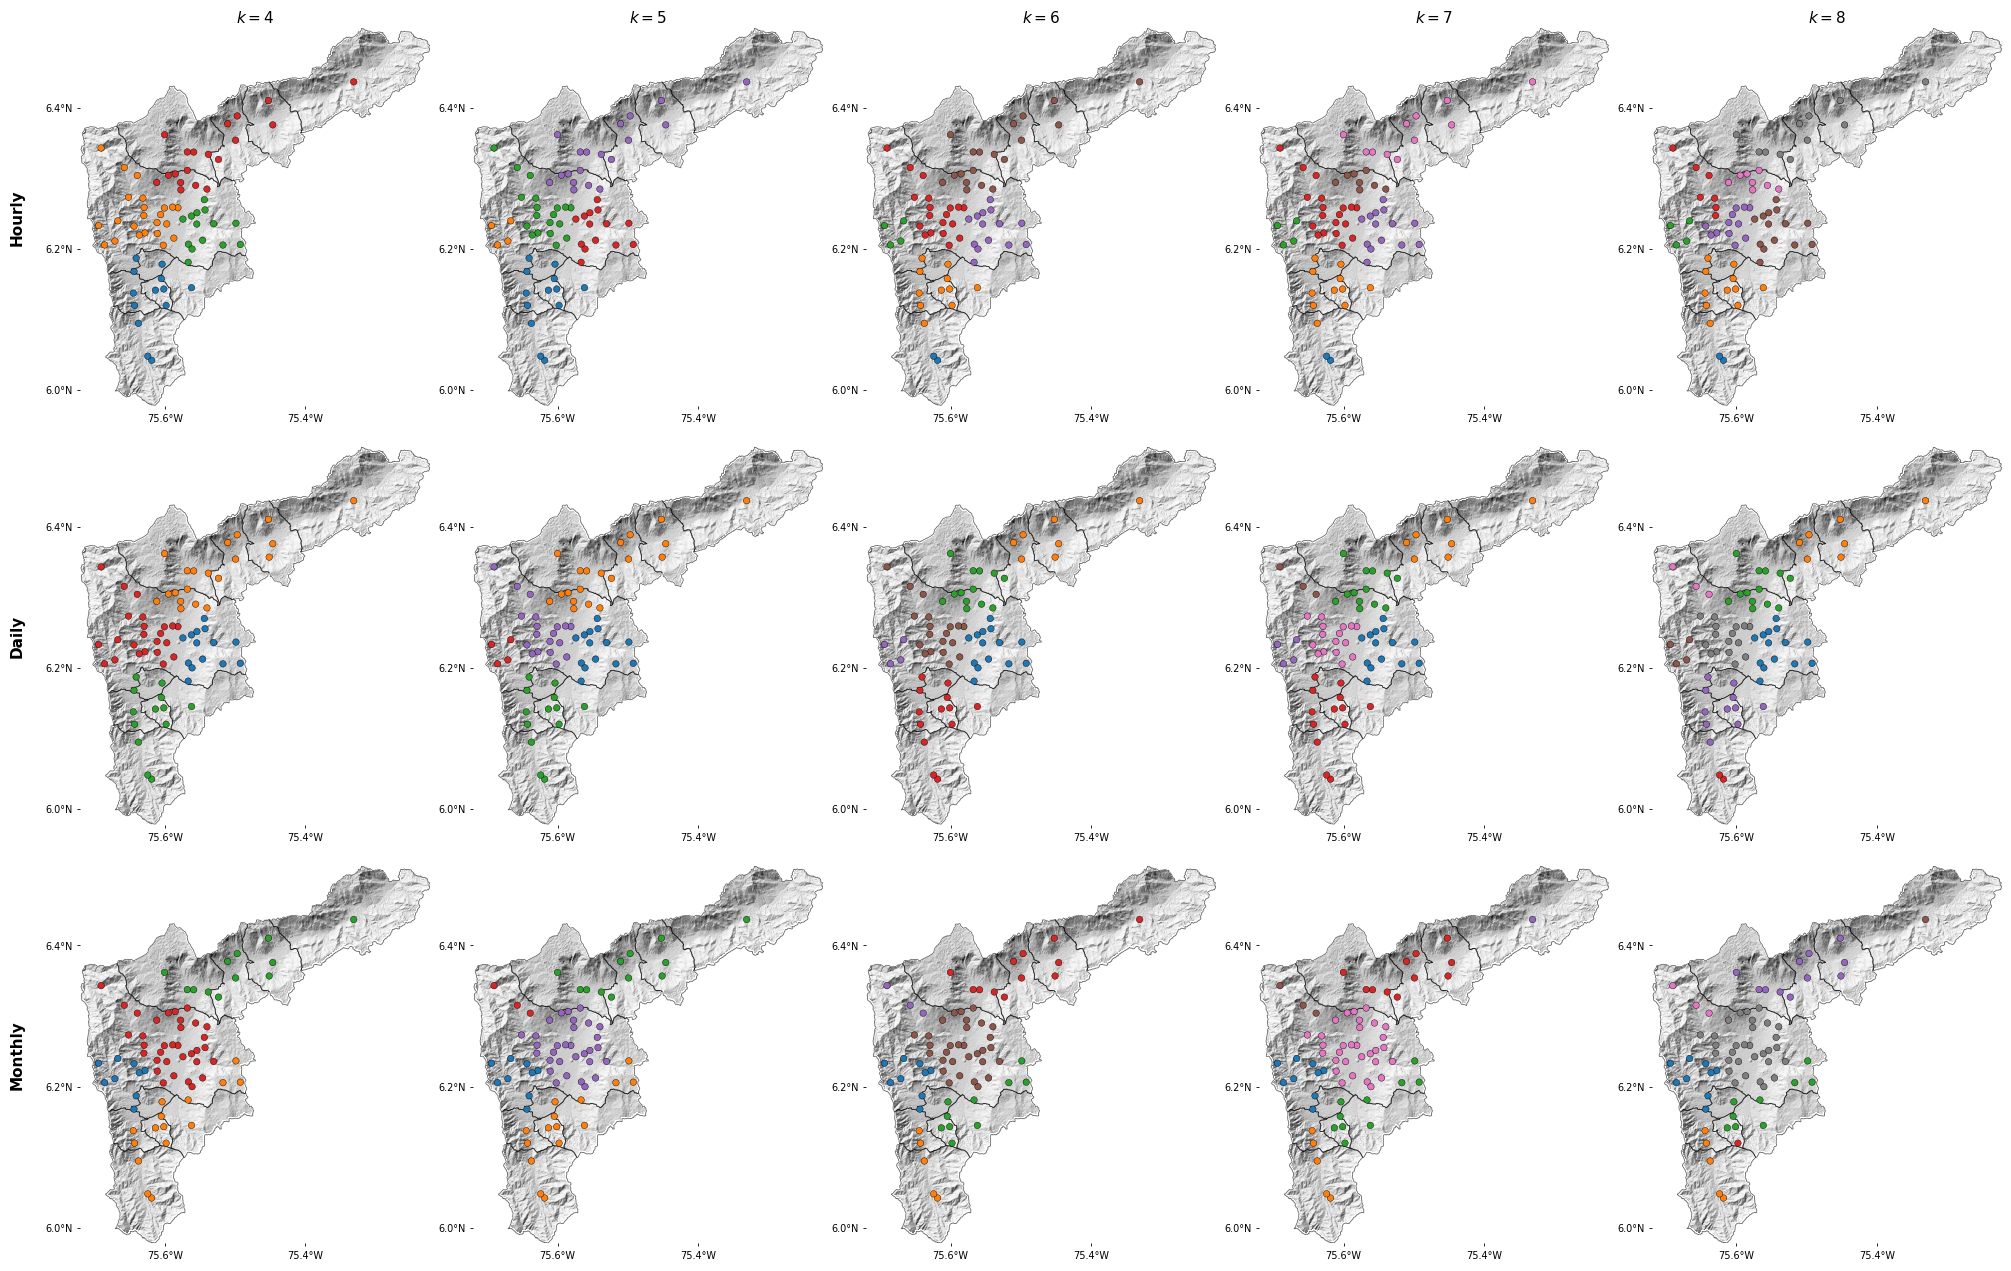

Figura guardada en: /home/oisanchezp/Thesis/results/02_Chapter/fig06.png


In [13]:
# ════════════════════════════════════════════════════════════════
# Figura comparativa: 3 filas (escalas) x 5 columnas (k=4..8)
# ════════════════════════════════════════════════════════════════
from matplotlib.colors import to_hex
#
# Paleta única, suficiente para k_max
palette_global = [to_hex(plt.cm.tab10(i)) for i in range(max(ks_candidates))]

fig, axes = plt.subplots(
    len(order_scales), len(ks_candidates),
    figsize=(4.0 * len(ks_candidates), 4.2 * len(order_scales)),
    constrained_layout=True
)

for i, (escala, escala_lbl) in enumerate(order_scales):
    gdf_base = trees[escala]["gdf"].copy()
    for j, k in enumerate(ks_candidates):
        ax = axes[i, j]

        labels = labels_k[(escala, k)].reindex(gdf_base.index).values
        # Colores por cluster (los clusters NO comparten id entre escalas o k)
        uniq = np.sort(np.unique(labels))
        colmap = {cl: palette_global[idx % len(palette_global)]
                  for idx, cl in enumerate(uniq)}
        colors = [colmap[c] for c in labels]

        # Hillshade + AMVA + puntos
        show(hill, transform=hill_src.transform, ax=ax, cmap="Greys_r")
        AMVA.plot(ax=ax, facecolor="none", edgecolor="black",
                  linewidth=0.6, alpha=0.6)
        gdf_base.plot(ax=ax, color=colors, edgecolor="black",
                      markersize=22, linewidth=0.3, zorder=3)

        # Cosmética
        for side in ["top", "right", "bottom", "left"]:
            ax.spines[side].set_visible(False)
        ax.tick_params(axis="both", which="both", length=2, width=0.6,
                       labelsize=7)
        ax.xaxis.set_major_locator(MaxNLocator(3))
        ax.yaxis.set_major_locator(MaxNLocator(3))
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f"{abs(x):.1f}°W"))
        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda y, _: f"{y:.1f}°N"))
        ax.grid(False)

        # Títulos: columna = k (solo fila superior), fila = escala (solo col izq)
        if i == 0:
            ax.set_title(f"$k={k}$", fontsize=11, fontweight="bold", pad=4)
        if j == 0:
            ax.text(-0.18, 0.5, escala_lbl, transform=ax.transAxes,
                    fontsize=11, fontweight="bold", rotation=90,
                    ha="center", va="center")

# Guardar
out_fig = "/home/oisanchezp/Thesis/results/02_Chapter/fig06.png"
os.makedirs(os.path.dirname(out_fig), exist_ok=True)
fig.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {out_fig}")

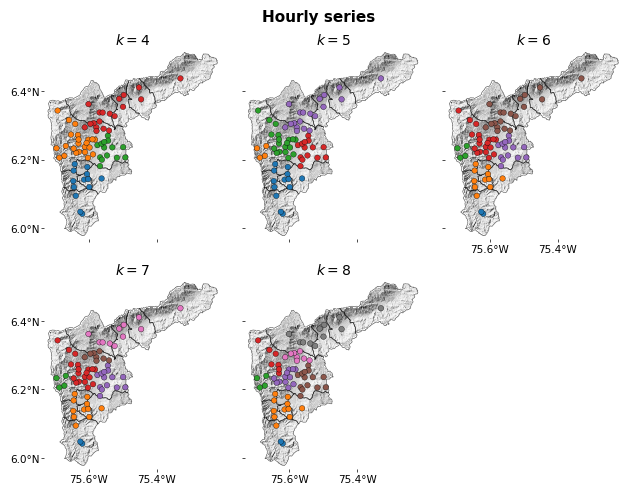

Figura guardada en: /home/oisanchezp/Thesis/results/02_Chapter/fig06_hourly.png


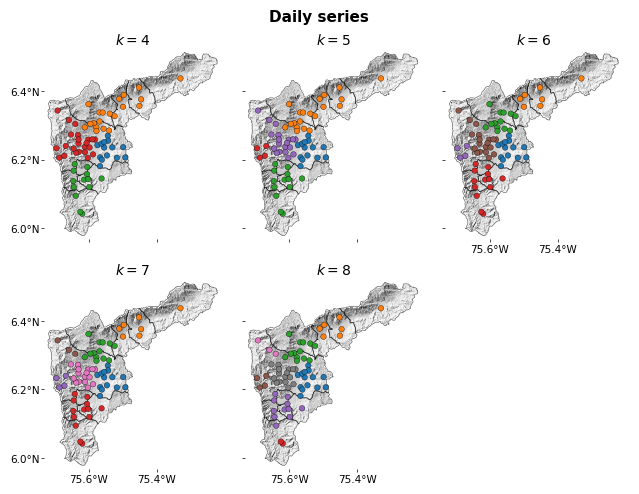

Figura guardada en: /home/oisanchezp/Thesis/results/02_Chapter/fig06_daily.png


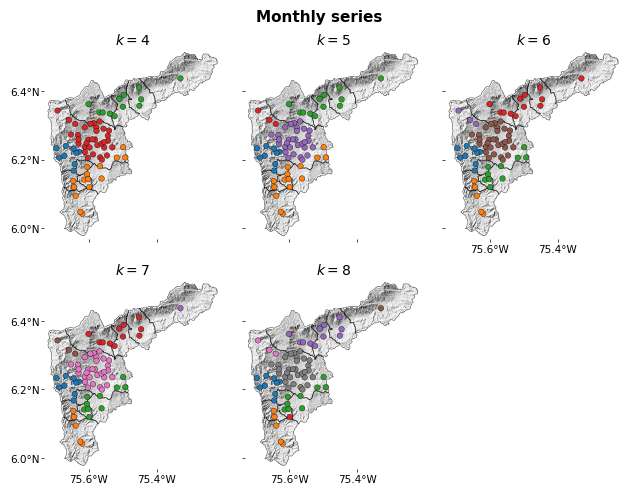

Figura guardada en: /home/oisanchezp/Thesis/results/02_Chapter/fig06_monthly.png


In [15]:
# ════════════════════════════════════════════════════════════════
# TRES figuras separadas (una por escala): 2 filas x 3 columnas (k=4..8)
#   Fila 1: k=4, 5, 6      Fila 2: k=7, 8  (+ hueco vacío abajo a la derecha)
#
# Cambio clave respecto a la versión 1x5: la figura se construye al TAMAÑO
# FINAL impreso (\textwidth), no gigante para luego encogerla en LaTeX.
# Así los tamaños de fuente en puntos son los que realmente se ven en el PDF.
# En LaTeX: \includegraphics[width=\textwidth]{...}  (SIN factor de escala)
# ════════════════════════════════════════════════════════════════
from matplotlib.colors import to_hex
 
# ---- Parámetros de tamaño (los únicos que normalmente tocarás) --------------
FIG_W_IN      = 6.3    # ancho de \textwidth en pulgadas (16 cm ≈ 6.3 in)
PANEL_ASPECT  = 1.15   # alto/ancho de cada mapa; súbelo si el valle sale cortado
FS_TITLE      = 10     # tamaño del "k = 4" (pt reales en el PDF)
FS_TICKS      = 7.5    # tamaño de las coordenadas
FS_SUPTITLE   = 11     # tamaño de "Hourly series"
MARKER_SIZE   = 16     # área del punto (pt^2)
SHOW_SUPTITLE = True   # False si el caption ya dice la escala
# ----------------------------------------------------------------------------
 
NCOLS, NROWS = 3, 2
 
palette_global = [to_hex(plt.cm.tab10(i)) for i in range(max(ks_candidates))]
 
out_base = "/home/oisanchezp/Thesis/results/02_Chapter"
os.makedirs(out_base, exist_ok=True)
 
# Extensión común: recorta el hillshade sobrante y garantiza que los 5 mapas
# queden exactamente a la misma escala.
xmin, ymin, xmax, ymax = AMVA.total_bounds
padx = 0.02 * (xmax - xmin)
pady = 0.02 * (ymax - ymin)
 
panel_w = FIG_W_IN / NCOLS
fig_h   = panel_w * PANEL_ASPECT * NROWS
 
for escala, escala_lbl in order_scales:
    gdf_base = trees[escala]["gdf"].copy()
 
    fig, axes = plt.subplots(
        NROWS, NCOLS,
        figsize=(FIG_W_IN, fig_h),
        constrained_layout=True,
    )
    axes = axes.ravel()
 
    for j, k in enumerate(ks_candidates):
        ax = axes[j]
        row, col = divmod(j, NCOLS)
 
        labels = labels_k[(escala, k)].reindex(gdf_base.index).values
 
        # Colores por cluster (independientes por panel)
        uniq = np.sort(np.unique(labels))
        colmap = {cl: palette_global[idx % len(palette_global)]
                  for idx, cl in enumerate(uniq)}
        colors = [colmap[c] for c in labels]
 
        # Hillshade + AMVA + puntos
        show(hill, transform=hill_src.transform, ax=ax, cmap="Greys_r")
        AMVA.plot(ax=ax, facecolor="none", edgecolor="black",
                  linewidth=0.5, alpha=0.6)
        gdf_base.plot(ax=ax, color=colors, edgecolor="black",
                      markersize=MARKER_SIZE, linewidth=0.25, zorder=3)
 
        # Misma ventana geográfica en los 5 paneles (después de plotear)
        ax.set_xlim(xmin - padx, xmax + padx)
        ax.set_ylim(ymin - pady, ymax + pady)
 
        # Cosmética
        for side in ["top", "right", "bottom", "left"]:
            ax.spines[side].set_visible(False)
        ax.tick_params(axis="both", which="both", length=2, width=0.5,
                       labelsize=FS_TICKS, pad=1.5)
        ax.xaxis.set_major_locator(MaxNLocator(3))
        ax.yaxis.set_major_locator(MaxNLocator(3))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.1f}°W"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}°N"))
        ax.grid(False)
        ax.set_title(f"$k={k}$", fontsize=FS_TITLE, fontweight="bold", pad=3)
 
        # Etiquetas solo en el borde exterior de la rejilla:
        #  - latitudes  -> solo primera columna
        #  - longitudes -> solo si NO hay otro panel debajo
        if col > 0:
            ax.set_yticklabels([])
        if (j + NCOLS) < len(ks_candidates):
            ax.set_xticklabels([])
 
    # Apagar los ejes sobrantes (el hueco inferior derecho)
    for ax in axes[len(ks_candidates):]:
        ax.set_axis_off()
 
    if SHOW_SUPTITLE:
        fig.suptitle(f"{escala_lbl} series", fontsize=FS_SUPTITLE,
                     fontweight="bold")
 
    out_fig = os.path.join(out_base, f"fig06_{escala}.png")
    fig.savefig(out_fig, dpi=400, bbox_inches="tight")
    plt.show()
    print(f"Figura guardada en: {out_fig}")

## **Matriz ARI entre escalas para k=5 (y opcionalmente para otros k)**

Adjusted Rand Index between scales for each k

  k = 4
         hourly  daily  monthly
hourly    1.000  1.000    0.289
daily     1.000  1.000    0.298
monthly   0.289  0.298    1.000

  k = 5
         hourly  daily  monthly
hourly    1.000   1.00    0.301
daily     1.000   1.00    0.310
monthly   0.301   0.31    1.000

  k = 6
         hourly  daily  monthly
hourly    1.000  0.866    0.269
daily     0.866  1.000    0.264
monthly   0.269  0.264    1.000

  k = 7
         hourly  daily  monthly
hourly    1.000  0.789    0.322
daily     0.789  1.000    0.294
monthly   0.322  0.294    1.000

  k = 8
         hourly  daily  monthly
hourly    1.000  0.780    0.295
daily     0.780  1.000    0.291
monthly   0.295  0.291    1.000

Resumen: ARI pareados y promedio por k
   ARI_hourly_daily  ARI_hourly_monthly  ARI_daily_monthly  ARI_mean
k                                                                   
4             1.000               0.289              0.298     0.529
5             1.000   

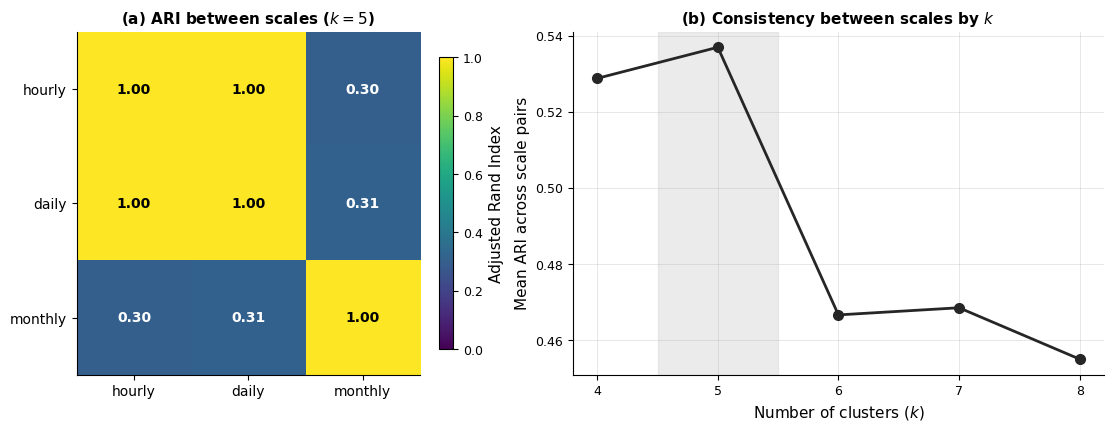


Figura ARI guardada en: /home/oisanchezp/Thesis/results/02_Chapter/fig07.png


In [14]:
# ════════════════════════════════════════════════════════════════
# Matriz ARI entre escalas temporales para cada k candidato
# ════════════════════════════════════════════════════════════════
ari_matrices = {}

for k in ks_candidates:
    labels_dict = {escala: labels_k[(escala, k)] for escala, _ in order_scales}
    ari_matrices[k] = ari_between_scales(labels_dict)

# Mostrar todas las matrices apiladas
print("=" * 60)
print("Adjusted Rand Index between scales for each k")
print("=" * 60)
for k in ks_candidates:
    print(f"\n  k = {k}")
    print(ari_matrices[k].round(3).to_string())

# Resumen: ARI medio fuera de la diagonal (medida de consistencia entre escalas)
ari_summary = pd.DataFrame({
    "ARI_hourly_daily":  [ari_matrices[k].loc["hourly",  "daily"]   for k in ks_candidates],
    "ARI_hourly_monthly":[ari_matrices[k].loc["hourly",  "monthly"] for k in ks_candidates],
    "ARI_daily_monthly": [ari_matrices[k].loc["daily",   "monthly"] for k in ks_candidates],
}, index=ks_candidates)
ari_summary["ARI_mean"] = ari_summary.mean(axis=1)
ari_summary.index.name = "k"

print("\n" + "=" * 60)
print("Resumen: ARI pareados y promedio por k")
print("=" * 60)
print(ari_summary.round(3))

# Figura compacta: heatmap del ARI para k=5 + barra de ARI medio vs k
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True,
                                gridspec_kw={"width_ratios": [1, 1.4]})

# (a) Heatmap ARI para k = 5
M5 = ari_matrices[5]
im = ax1.imshow(M5.values.astype(float), cmap="viridis", vmin=0, vmax=1)
ax1.set_xticks(range(len(M5)))
ax1.set_yticks(range(len(M5)))
ax1.set_xticklabels(M5.columns, fontsize=10)
ax1.set_yticklabels(M5.index, fontsize=10)
for i in range(len(M5)):
    for j in range(len(M5)):
        ax1.text(j, i, f"{M5.values[i, j]:.2f}",
                 ha="center", va="center",
                 color="white" if M5.values[i, j] < 0.6 else "black",
                 fontsize=10, fontweight="bold")
ax1.set_title("(a) ARI between scales ($k=5$)", fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax1, shrink=0.85, label="Adjusted Rand Index")

# (b) ARI medio para cada k candidato
ax2.plot(ari_summary.index, ari_summary["ARI_mean"],
         color="0.15", marker="o", linewidth=2, markersize=7)
ax2.axvspan(4.5, 5.5, color="0.85", alpha=0.5, zorder=0)
ax2.set_xticks(list(ks_candidates))
ax2.set_xlabel("Number of clusters ($k$)")
ax2.set_ylabel("Mean ARI across scale pairs")
ax2.set_title("(b) Consistency between scales by $k$",
              fontsize=11, fontweight="bold")
ax2.grid(True, alpha=0.3, linewidth=0.7)
ax2.spines[["top", "right"]].set_visible(False)

out_fig_ari = "/home/oisanchezp/Thesis/results/02_Chapter/fig07.png"
fig.savefig(out_fig_ari, dpi=300, bbox_inches="tight")
plt.show()
print(f"\nFigura ARI guardada en: {out_fig_ari}")

In [13]:
# ════════════════════════════════════════════════════════════════
# Generador LaTeX — Tabla resumen del ARI por k
# (ARI pareado entre escalas + ARI medio)
# ════════════════════════════════════════════════════════════════
def ari_summary_to_latex(ari_summary, precision=3, out_path=None):
    """
    Convierte el resumen ARI a una tabla LaTeX en formato tabularx
    con el mismo estilo que tab:kselect.

    Columnas: k | ARI(hourly,daily) | ARI(hourly,monthly) |
              ARI(daily,monthly) | Mean ARI

    Parameters
    ----------
    ari_summary : pd.DataFrame con índice k y 4 columnas
                  (ARI_hourly_daily, ARI_hourly_monthly,
                   ARI_daily_monthly, ARI_mean).
    precision : decimales para los valores ARI.
    out_path : ruta para guardar el .tex (opcional).
    """
    col_labels = [
        r"\textbf{ARI}\textsubscript{H--D}",
        r"\textbf{ARI}\textsubscript{H--M}",
        r"\textbf{ARI}\textsubscript{D--M}",
        r"\textbf{Mean ARI}",
    ]
    cols_data = ["ARI_hourly_daily", "ARI_hourly_monthly",
                 "ARI_daily_monthly", "ARI_mean"]

    # Identificar el k con ARI medio máximo (para negrita)
    k_best = ari_summary["ARI_mean"].idxmax()

    # Cabecera
    header = r"\textbf{$k$} & " + " & ".join(col_labels) + r" \\"

    # Cuerpo
    body_lines = []
    for k_val, row in ari_summary.iterrows():
        cells = [str(k_val)]
        for c in cols_data:
            v = row[c]
            txt = f"{v:.{precision}f}"
            # Negrita en la fila con mayor mean ARI
            if k_val == k_best:
                txt = rf"\textbf{{{txt}}}"
            cells.append(txt)
        row_str = " & ".join(cells) + r" \\"
        if k_val == k_best:
            row_str = rf"\textbf{{{k_val}}} & " + " & ".join(cells[1:]) + r" \\"
        body_lines.append(row_str)

    body_block = "\n\\hline\n".join(body_lines)

    # Columnas: m{0.8cm} + 4 columnas Y
    col_spec = r">{\centering\arraybackslash}m{0.8cm} Y Y Y Y"

    tex = (
        "\\renewcommand{\\arraystretch}{1.25}\n"
        "\\setlength{\\tabcolsep}{6pt}\n"
        "\\begin{table}[h]\n"
        "\\centering\n"
        "\\newcolumntype{Y}{>{\\centering\\arraybackslash}X}\n"
        f"\\begin{{tabularx}}{{\\textwidth}}{{{col_spec}}}\n"
        "\\hline\n"
        f"{header}\n"
        "\\hline\n"
        f"{body_block}\n"
        "\\hline\n"
        "\\end{tabularx}\n"
        "\\caption{Adjusted Rand Index (ARI) between the partitions "
        "obtained at the hourly (H), daily (D) and monthly (M) "
        "aggregations for each candidate $k$. "
        "ARI\\textsubscript{H--D}, ARI\\textsubscript{H--M} and "
        "ARI\\textsubscript{D--M} are the pairwise ARI values; "
        "the last column is the mean of the three pairs and provides a "
        "single scalar measure of cross-scale consistency. "
        "ARI ranges from $0$ (random agreement) to $1$ (identical "
        "partitions); values above approximately $0.6$ indicate strong "
        "agreement. The row corresponding to the maximum mean ARI "
        f"($k={k_best}$) is highlighted in bold.}}\n"
        "\\label{tab:ari_summary}\n"
        "\\end{table}\n"
    )

    if out_path is not None:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(tex)
        print(f"\nTabla ARI LaTeX guardada en: {out_path}")

    return tex


out_tex_ari = "/home/oisanchezp/Thesis/results/03_Chapter/tab_ari_summary.tex"
tex_ari = ari_summary_to_latex(
    ari_summary,
    precision=3,
    out_path=out_tex_ari,
)

print("\n" + "=" * 70)
print("Vista previa del LaTeX generado (tabla ARI):")
print("=" * 70)
print(tex_ari)


Tabla ARI LaTeX guardada en: /home/oisanchezp/Thesis/results/03_Chapter/tab_ari_summary.tex

Vista previa del LaTeX generado (tabla ARI):
\renewcommand{\arraystretch}{1.25}
\setlength{\tabcolsep}{6pt}
\begin{table}[h]
\centering
\newcolumntype{Y}{>{\centering\arraybackslash}X}
\begin{tabularx}{\textwidth}{>{\centering\arraybackslash}m{0.8cm} Y Y Y Y}
\hline
\textbf{$k$} & \textbf{ARI}\textsubscript{H--D} & \textbf{ARI}\textsubscript{H--M} & \textbf{ARI}\textsubscript{D--M} & \textbf{Mean ARI} \\
\hline
4 & 1.000 & 0.289 & 0.298 & 0.529 \\
\hline
\textbf{5} & \textbf{1.000} & \textbf{0.301} & \textbf{0.310} & \textbf{0.537} \\
\hline
6 & 0.866 & 0.269 & 0.264 & 0.467 \\
\hline
7 & 0.789 & 0.322 & 0.294 & 0.468 \\
\hline
8 & 0.780 & 0.295 & 0.291 & 0.455 \\
\hline
\end{tabularx}
\caption{Adjusted Rand Index (ARI) between the partitions obtained at the hourly (H), daily (D) and monthly (M) aggregations for each candidate $k$. ARI\textsubscript{H--D}, ARI\textsubscript{H--M} and ARI\texts